# Media Source Extraction Pipeline

```
Setup & data load
  → Step 1:  Split cells into individual source candidates
  → Step 2:  Clean each string
  → Step 3:  Frequency table + distribution chart (visualise how many sources vs how many mentions)
  → Step 4:  Extract frequent names (>3 mentions) from long sentences → new freq table + chart
  → Step 5:  Social-media column audit — what did people write in Facebook/Instagram/etc?
  → Step 6:  Unification — all hardcoded dictionaries (MM + SM aliases, noise filter, normalisation) applied to ALL sources
  → Step 7:  Frequency table after unification + distribution chart
  → Step 8:  Stratified Sampling 50

```


# Setup and data load

In [1]:
import pandas as pd
import re
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from collections import Counter
from openpyxl.styles import Alignment
from openpyxl.utils import get_column_letter

df = pd.read_csv('media_sources_internship.csv')
print(df.shape)
print(list(df.columns))

(928, 21)
['PROLIFIC_PID', 'Facebook', 'Facebook_freq', 'Instagram', 'Instagram_freq', 'TV news programs', 'TV news programs_freq', 'TikTok', 'TikTok_freq', 'Twitter/X', 'Twitter/X_freq', 'YouTube', 'YouTube_freq', 'online news sites', 'online news sites_freq', 'podcasts', 'podcasts_freq', 'printed newspapers', 'printed newspapers_freq', 'the radio', 'the radio_freq']


In [2]:
# Survey columns where the platform itself is social media
SM_SURVEY_COLS = ['Facebook', 'Instagram', 'TikTok', 'Twitter/X', 'YouTube']

# Survey columns for traditional media
MM_SURVEY_COLS = ['TV news programs', 'online news sites', 'podcasts',
                  'printed newspapers', 'the radio']

# All free-text columns (drop ID and pre-aggregated freq columns)
source_cols = [c for c in df.columns
               if not c.endswith('_freq') and c != 'PROLIFIC_PID']

# Stack into one long Series, keep track of which column each entry came from
all_text_with_col = (
    df[source_cols]
    .stack()
    .reset_index()
    .rename(columns={'level_1': 'survey_col', 0: 'text'})
    .assign(text=lambda d: d['text'].astype(str))
)
all_text = all_text_with_col['text']
print(f"Total cells: {len(all_text)}")

Total cells: 2771


# Step 1: Split cells into individual source candidates

Cells contain multiple sources separated by commas, semicolons, newlines, or 'and'.
'and' is tricky — only split on it when the text to the left is ≤30 chars (likely a short name, not a sentence).
Sources whose names contain 'and' go in PROTECTED_NAMES — never split those.

In [3]:
PROTECTED_NAMES = {
    'aba and preach',
    'faith and freedom coalition',
    'guns and butter',
    'law and crime',
    'crime and justice',
    'meet the press',
    'msnbc',  # kept separate — 'meet the press' is a program, 'msnbc' is a channel
    'breaking points with krystal and saagar',
}

def split_sources(text):
    # Split on clear delimiters — never part of a source name
    segs = re.split(r'[;,\n:/]|\.\.\.+', text)
    result = []
    for seg in segs:
        if seg.strip().lower() in PROTECTED_NAMES:
            result.append(seg)
            continue
        parts = re.split(r'\s+and\s+', seg, flags=re.IGNORECASE)
        if len(parts) == 1:
            result.append(seg)
        else:
            current = parts[0]
            for nxt in parts[1:]:
                if len(current.strip()) <= 30:
                    # Short left side → 'and' is a list separator, e.g. 'CNN and BBC'
                    result.append(current)
                    current = nxt
                else:
                    # Long left side → 'and' is part of the text, keep together
                    current = current + ' and ' + nxt
            result.append(current)
    return [s.strip() for s in result if s.strip()]
 

# Step 2: Clean each candidate string

Lowercase, strip URLs, remove domain endings, remove noise punctuation.
Also record which survey column the entry came from — needed later for MM-in-SM detection.

In [4]:
def clean(s):
    s = s.lower()
    s = re.sub(r'https?://|www\.|//', '', s)
    # .co.uk before .co so we catch the full thing
    s = re.sub(r'\.co\.uk|\.com|\.org|\.net|\.co|\.uk|\.gov|\.edu', '', s)
    s = s.replace('_', ' ')
    s = re.sub(r'[@™\'\"()\[\]]', '', s)
    s = s.encode('ascii', 'ignore').decode('ascii')
    s = s.strip(' /-.')
    return s

# Explode: one row per split+cleaned piece, keeping survey_col
rows = []
for _, row in all_text_with_col.iterrows():
    for piece in split_sources(row['text']):
        c = clean(piece)
        if c:
            rows.append({
                'cleaned':    c,
                'survey_col': row['survey_col'],
                'col_type':   'SM_col' if row['survey_col'] in SM_SURVEY_COLS else 'MM_col',
            })

exploded = pd.DataFrame(rows)
all_cleaned = exploded['cleaned']

print(f"Total mentions (with repeats): {len(all_cleaned)}")
print(f"Unique strings: {all_cleaned.nunique()}")

Total mentions (with repeats): 6355
Unique strings: 2506


# Step 3: Frequency table

Count how often each unique string appears.
We focus on strings mentioned >3 times — these are the ones worth spending effort on.

In [5]:
# Frequency table based on MENTIONS (one respondent writing CNN in 2 columns = 2)
freq = all_cleaned.value_counts().reset_index()
freq.columns = ['source', 'count']
freq['cumulative_pct'] = (freq['count'].cumsum() / freq['count'].sum() * 100).round(1)

top = freq[freq['count'] > 3].copy()
print(f"Strings mentioned more than 3 times: {len(top)}")
print(f"These cover {top['count'].sum()} of {len(all_cleaned)} total mentions "
      f"({top['count'].sum()/len(all_cleaned)*100:.1f}%)")
print()
with pd.option_context('display.max_rows', 300, 'display.max_colwidth', 60):
    print(top.to_string())

# Frequency table based on UNIQUE RESPONDENTS
# (CNN written by same person in Facebook + Instagram = counted once)
respondent_source = (
    exploded[['survey_col', 'cleaned']]
    .copy()
    .assign(respondent_id=lambda d: exploded.index // len(source_cols))
)
# Use the original df index to get respondent — exploded was built row-by-row over df
# Attach respondent id from the original df row
rows_with_pid = []
for df_idx, row in df.iterrows():
    for col in source_cols:
        val = str(row[col])
        for piece in split_sources(val):
            c = clean(piece)
            if c:
                rows_with_pid.append({'cleaned': c, 'respondent_id': df_idx})

exploded_with_pid = pd.DataFrame(rows_with_pid)

# Per respondent: deduplicate sources
unique_per_resp = exploded_with_pid.drop_duplicates(subset=['respondent_id', 'cleaned'])
freq_unique = unique_per_resp['cleaned'].value_counts().reset_index()
freq_unique.columns = ['source', 'unique_respondents']

top_unique = freq_unique[freq_unique['unique_respondents'] > 3].copy()

print(f"\nUnique-respondent table: strings mentioned by >3 unique respondents: {len(top_unique)}")
print()
with pd.option_context('display.max_rows', 300, 'display.max_colwidth', 60):
    print(top_unique.head(40).to_string())

# Comparison: mention-based vs respondent-based top lists
top_sources_mentions = set(top['source'])
top_sources_unique   = set(top_unique['source'])
overlap = top_sources_mentions & top_sources_unique
only_mentions = top_sources_mentions - top_sources_unique
only_unique   = top_sources_unique - top_sources_mentions

print(f"\nComparison (>3 threshold):")
print(f"  Based on mentions:            {len(top_sources_mentions)} sources")
print(f"  Based on unique respondents:  {len(top_sources_unique)} sources")
print(f"  Overlap (in both):            {len(overlap)} sources")
print(f"  Only in mention-based:        {len(only_mentions)} — {sorted(only_mentions)[:10]}")
print(f"  Only in respondent-based:     {len(only_unique)}  — {sorted(only_unique)[:10]}")
print(f"\nOverlap % of mention-based: {len(overlap)/len(top_sources_mentions)*100:.1f}%")

# Check what % of frequent words are mainstream media (in ALIAS_MAP targets)
import re as _re
ALIAS_TARGETS = set(v for _, v in [
    ('cnn','CNN'),('fox news','Fox News'),('msnbc','MSNBC'),('abc news','ABC News'),
    ('nbc news','NBC News'),('cbs news','CBS News'),('bbc news','BBC News'),
    ('npr','NPR'),('new york times','New York Times'),('washington post','Washington Post'),
    ('wall street journal','Wall Street Journal'),('reuters','Reuters'),
    ('associated press','Associated Press'),('pbs newshour','PBS NewsHour'),
    ('al jazeera','Al Jazeera'),('cnbc','CNBC'),('usa today','USA Today'),
])
mention_mm = {s for s in top_sources_mentions if s in ALIAS_TARGETS or
              any(s == v for _,v in [('cnn','CNN')])}
# simpler: check by unifying and seeing if they map to known MM
print(f"\nNote: check categories after Step 6 to see what % of frequent words are mainstream media.")

# Unique-respondent frequency table
# One respondent writing CNN in both Facebook and Instagram counts as 1, not 2.
# We build this by attaching the original df row index (= respondent) to each entry.
rows_with_pid = []
for df_idx, row in df.iterrows():
    for col in source_cols:
        val = str(row[col])
        for piece in split_sources(val):
            c = clean(piece)
            if c:
                rows_with_pid.append({'cleaned': c, 'respondent_id': df_idx})

exploded_with_pid = pd.DataFrame(rows_with_pid)

# Drop duplicate (respondent, source) pairs — same source by same person counts once
unique_per_resp = exploded_with_pid.drop_duplicates(subset=['respondent_id', 'cleaned'])
freq_unique = unique_per_resp['cleaned'].value_counts().reset_index()
freq_unique.columns = ['source', 'unique_respondents']

top_unique = freq_unique[freq_unique['unique_respondents'] > 3].copy()

print(f"\nUnique-respondent table: sources mentioned by >3 unique respondents: {len(top_unique)}")
with pd.option_context('display.max_rows', 300, 'display.max_colwidth', 60):
    print(top_unique.head(40).to_string())

# Compare the two tables
top_sources_mentions = set(top['source'])
top_sources_unique   = set(top_unique['source'])
overlap      = top_sources_mentions & top_sources_unique
only_mention = top_sources_mentions - top_sources_unique
only_uniq    = top_sources_unique - top_sources_mentions

print(f"\nComparison (>3 threshold):")
print(f"  Mention-based list:           {len(top_sources_mentions)} sources")
print(f"  Unique-respondent list:       {len(top_sources_unique)} sources")
print(f"  Overlap:                      {len(overlap)} ({len(overlap)/len(top_sources_mentions)*100:.1f}% of mention-based)")
print(f"  Only in mention-based:        {sorted(only_mention)[:10]}")
print(f"  Only in respondent-based:     {sorted(only_uniq)[:10]}")
print()
print("If overlap is high (>90%), both lists are equivalent and the mention-based")
print("candidate_names used in Step 4 is a good proxy for 'sources many people use'.")
print("If overlap is low, consider switching Step 4 to use the respondent-based list.")


Strings mentioned more than 3 times: 161
These cover 3629 of 6355 total mentions (57.1%)

                      source  count  cumulative_pct
0                        cnn    623             9.8
1                   fox news    188            12.8
2                      msnbc    184            15.7
3                        npr    157            18.1
4             new york times    139            20.3
5                        bbc    130            22.4
6                        nbc    114            24.2
7                        abc    106            25.8
8            washington post     89            27.2
9                        fox     89            28.6
10                       cbs     81            29.9
11                   reuters     64            30.9
12                  abc news     52            31.7
13               google news     45            32.4
14                      cnbc     44            33.1
15        the new york times     44            33.8
16       wall street journ

# Step 3a: Distribution chart

X axis = number of mentions (count).
Y axis = how many unique strings have that count.
This shows whether the data is dominated by a few very common sources or spread across many rare ones.

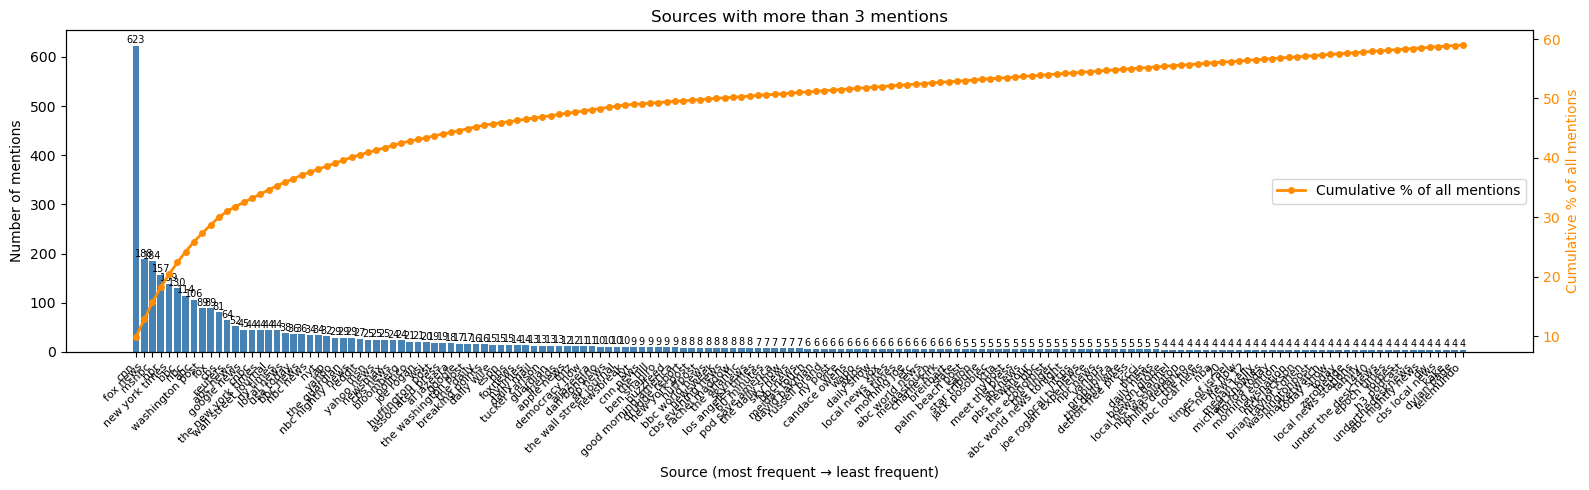

Total mentions in dataset: 6355

  Top  1 sources cover 623 of 6355 mentions (9.8%)
  Top  5 sources cover 1291 of 6355 mentions (20.3%)
  Top 10 sources cover 1819 of 6355 mentions (28.6%)
  Top 20 sources cover 2311 of 6355 mentions (36.4%)
  Top 40 sources cover 2819 of 6355 mentions (44.4%)
  Top 80 sources cover 3240 of 6355 mentions (51.0%)
  Top 161 sources cover 3629 of 6355 mentions (57.1%)


In [6]:
total_mentions = freq['count'].sum()
top_sources = freq.head(161).copy()
top_sources['pct'] = (top_sources['count'] / total_mentions * 100).round(1)
top_sources['cumulative_pct'] = top_sources['pct'].cumsum().round(1)

fig, ax = plt.subplots(figsize=(16, 5))
bars = ax.bar(top_sources['source'], top_sources['count'], color='steelblue')
ax.set_xlabel('Source (most frequent → least frequent)')
ax.set_ylabel('Number of mentions')
ax.set_title('Sources with more than 3 mentions')
plt.xticks(rotation=45, ha='right', fontsize=8)
for bar, val in zip(bars, top_sources['count']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            str(val), ha='center', va='bottom', fontsize=7)

# Cumulative count line — shows how many total mentions are covered as you add more sources
ax2 = ax.twinx()
ax2.plot(top_sources['source'], top_sources['cumulative_pct'], color='darkorange',
         marker='o', markersize=4, linewidth=2, label='Cumulative % of all mentions')
ax2.set_ylabel('Cumulative % of all mentions', color='darkorange')
ax2.tick_params(axis='y', labelcolor='darkorange')
ax2.legend(loc='center right')

plt.tight_layout()
plt.savefig('dist_step3.png', dpi=150)
plt.show()

print(f"Total mentions in dataset: {total_mentions}")
print()
for n in [1, 5, 10, 20, 40, 80, 161]:
    covered = top_sources.head(n)['count'].sum()
    print(f"  Top {n:2d} sources cover {covered} of {total_mentions} mentions ({covered/total_mentions*100:.1f}%)")

# Step 3b: How many strings contain 'like' or 'from'?

These are sentences where a source name is embedded after like and from.
We want to know how common it is.

In [7]:
long_strings = all_cleaned

like_mask = long_strings.str.contains(r'\blike\b', regex=True, na=False)
from_mask = long_strings.str.contains(r'\bfrom\b', regex=True, na=False)

print(f"Total cleaned strings:         {len(all_cleaned)}")
print(f"Long strings (>=25 chars):     {len(all_cleaned)} ({len(all_cleaned)/len(all_cleaned)*100:.1f}%)")
print(f"  containing 'like':           {like_mask.sum()}")
print(f"  containing 'from':           {from_mask.sum()}")
print()
print("Sample 'like' sentences:")
for s in long_strings[like_mask].head(8).tolist():
    print(f"  {repr(s)}")
print()
print("Sample 'from' sentences:")
for s in long_strings[from_mask].head(8).tolist():
    print(f"  {repr(s)}")

Total cleaned strings:         6355
Long strings (>=25 chars):     6355 (100.0%)
  containing 'like':           15
  containing 'from':           47

Sample 'like' sentences:
  'show pages that i follow like the black keys'
  'content creators that i follow like arnold'
  'i check out some of what is trending and get entertainment news from figures that i follow like arnold'
  'entertainment news like movieweb'
  'entertainment news from various content creators like alanah pearce'
  'news sources on specific issues like woods hole oceanagraphic institute'
  'local news youtube channels like wral'
  'maybe some random other videos like hasan that i only watch occasionally'

Sample 'from' sentences:
  'film news from bands'
  'entertainment news from actors'
  'i check out some of what is trending and get entertainment news from figures that i follow like arnold'
  'political news from the majority report'
  'entertainment news from various content creators like alanah pearce'
  'just w

# Step 4: Extract frequent words from long sentences

Instead of scanning for known names, we take all strings that appear >3 times and
look for them as substrings inside the long sentences.
The idea: if 'cnn' is frequent and a sentence contains 'cnn', we extract 'cnn'. 

In [8]:
freq_names = set(freq[freq['count'] > 3]['source'].tolist()) 
candidate_names = sorted(
    list(freq_names),
    key=len, reverse=True   # longest first — 'new york times' before 'times'
)
print(f"Candidate source names (frequent): {len(candidate_names)}")
print(f"Top 30: {candidate_names[:30]}")

Candidate source names (frequent): 161
Top 30: ['the wall street journal', 'abc world news tonight', 'joe rogan experience', 'good morning america', 'wall street journal', 'under the desk news', 'the washington post', 'local news stations', 'detroit free press', 'the new york times', 'brian taylor cohen', 'local news channel', 'los angeles times', 'cbs evening news', 'abc nightly news', 'pod save america', 'local news sites', 'nbc nightly news', 'associated press', 'underthedesknews', 'huffington post', 'washington post', 'times of israel', 'breaking points', 'philip defranco', 'morning edition', 'michael knowles', 'palm beach post', 'tucker carlson', 'nbc washington']


In [9]:
def extract_frequent(s, candidates):
    """Return all frequent names found as whole words inside s.
    If multiple candidates match (e.g. 'bbc or cnn'), each match becomes its own
    row via the explode() call below.  If nothing matches, return s unchanged.
    """
    found = [name for name in candidates
             if re.search(r'\b' + re.escape(name) + r'\b', s)]
    return found if found else [s]

# Explode multi-match results so 'bbc or cnn' → two separate rows
step4_series = all_cleaned.apply(lambda s: extract_frequent(s, candidate_names))
all_extracted_step4 = step4_series.explode().reset_index(drop=True)

# How many strings got resolved (changed)?
original_repeated = all_cleaned.loc[all_cleaned.index.repeat(
    step4_series.apply(len)
)].reset_index(drop=True)
resolved_4 = (all_extracted_step4 != original_repeated).sum()
unresolved_4 = len(all_extracted_step4) - resolved_4

print(f"  Rows after explode:             {len(all_extracted_step4)} (was {len(all_cleaned)})")
print(f"  Resolved by frequent-name scan: {resolved_4} ({resolved_4/len(all_extracted_step4)*100:.1f}%)")
print(f"  Still unresolved:               {unresolved_4}")

# Show some resolved examples
examples_4 = pd.DataFrame({
    'Before': original_repeated.values,
    'After':  all_extracted_step4.values
})
resolved_examples = examples_4[examples_4['Before'] != examples_4['After']]
print(f"\nSample resolved:")
with pd.option_context('display.max_colwidth', 90):
    print(resolved_examples.head(15).to_string())

  Rows after explode:             7433 (was 6355)
  Resolved by frequent-name scan: 1578 (21.2%)
  Still unresolved:               5855

Sample resolved:
                                                                 Before    After
15  entertainment news from various content creators like alanah pearce  various
20                                                       new york times    times
22                                                    los angeles times    times
23                                                                abc 7      abc
28                                                          google news   google
30                                                           yahoo news    yahoo
34                                                       new york times    times
38                                                       new york times    times
49                                                             fox news      fox
70                                  

In [10]:
# New frequency table after step 4
freq_4 = all_extracted_step4.value_counts().reset_index()
freq_4.columns = ['source', 'count']
freq_4['cumulative_pct'] = (freq_4['count'].cumsum() / freq_4['count'].sum() * 100).round(1)

top_4 = freq_4[freq_4['count'] > 3].copy()
unique_before = all_cleaned.nunique()
unique_after_4 = all_extracted_step4.nunique()

print(f"Unique strings before step 4: {unique_before}")
print(f"Unique strings after  step 4: {unique_after_4}")
print(f"Reduced by: {unique_before - unique_after_4} ({(unique_before-unique_after_4)/unique_before*100:.1f}%)")
print()
with pd.option_context('display.max_rows', 300, 'display.max_colwidth', 60):
    print(top_4.to_string())

Unique strings before step 4: 2506
Unique strings after  step 4: 2079
Reduced by: 427 (17.0%)

                      source  count  cumulative_pct
0                        cnn    654             8.8
1                        fox    321            13.1
2                      times    302            17.2
3                        nbc    208            20.0
4                        abc    207            22.8
5                      msnbc    200            25.5
6                        bbc    200            28.1
7                   fox news    196            30.8
8             new york times    193            33.4
9                        npr    192            36.0
10                       cbs    138            37.8
11           washington post    110            39.3
12                local news    105            40.7
13                    google     82            41.8
14                     today     67            42.7
15                   reuters     65            43.6
16                   

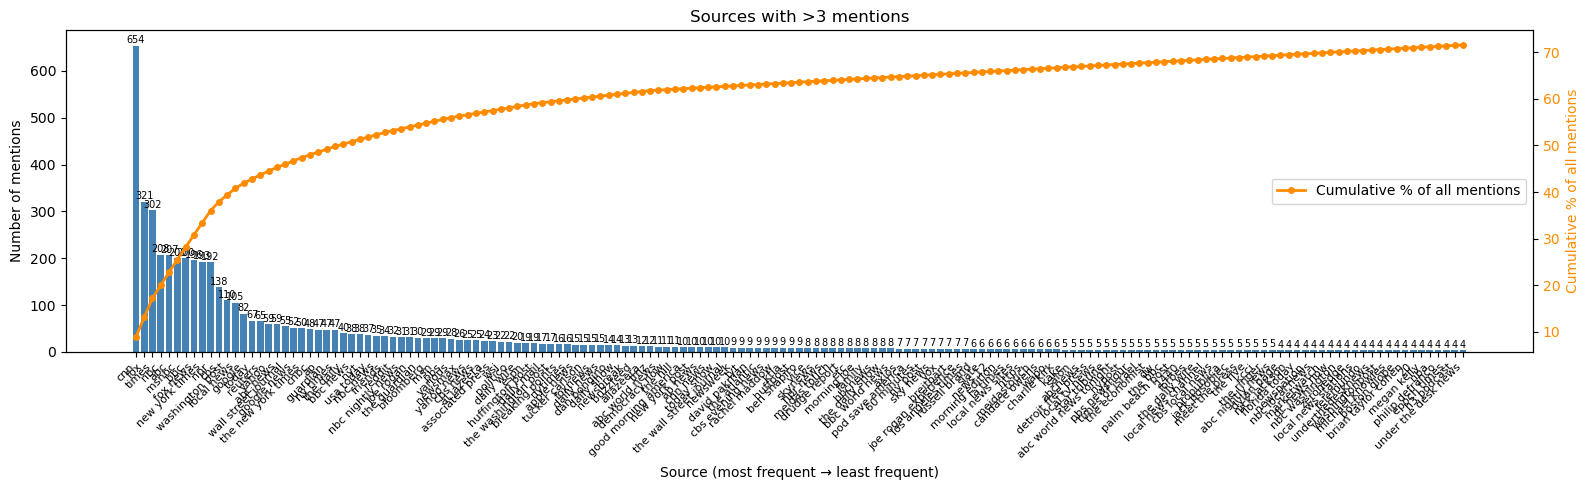

Total mentions in dataset: 7433

  Top  1 sources cover 654 of 7433 mentions (8.8%)
  Top  5 sources cover 1692 of 7433 mentions (22.8%)
  Top 10 sources cover 2673 of 7433 mentions (36.0%)
  Top 20 sources cover 3465 of 7433 mentions (46.6%)
  Top 40 sources cover 4191 of 7433 mentions (56.4%)
  Top 80 sources cover 4759 of 7433 mentions (64.0%)
  Top 161 sources cover 5207 of 7433 mentions (70.1%)


In [11]:
# Bar chart: top 40 sources on x axis, number of mentions on y axis
# Cumulative line shows how many total mentions are covered by the top N sources

total_mentions = freq_4['count'].sum()
top_sources = freq_4.head(161).copy()
top_sources['pct'] = (top_sources['count'] / total_mentions * 100).round(1)
top_sources['cumulative_pct'] = top_sources['pct'].cumsum().round(1)

fig, ax = plt.subplots(figsize=(16, 5))
bars = ax.bar(top_sources['source'], top_sources['count'], color='steelblue')
ax.set_xlabel('Source (most frequent → least frequent)')
ax.set_ylabel('Number of mentions')
ax.set_title('Sources with >3 mentions')
plt.xticks(rotation=45, ha='right', fontsize=8)
for bar, val in zip(bars, top_sources['count']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            str(val), ha='center', va='bottom', fontsize=7)

# Cumulative count line — shows how many total mentions are covered as you add more sources
ax2 = ax.twinx()
ax2.plot(top_sources['source'], top_sources['cumulative_pct'], color='darkorange',
         marker='o', markersize=4, linewidth=2, label='Cumulative % of all mentions')
ax2.set_ylabel('Cumulative % of all mentions', color='darkorange')
ax2.tick_params(axis='y', labelcolor='darkorange')
ax2.legend(loc='center right')

plt.tight_layout()
plt.savefig('dist_step4.png', dpi=150)
plt.show()

print(f"Total mentions in dataset: {total_mentions}")
print()
for n in [1, 5, 10, 20, 40, 80, 161]:
    covered = top_sources.head(n)['count'].sum()
    print(f"  Top {n:2d} sources cover {covered} of {total_mentions} mentions ({covered/total_mentions*100:.1f}%)")

# Step 5: Social-media column audit

What did people actually write in the Facebook / Instagram / TikTok / Twitter / YouTube columns?

We expect SM platform names — but some people wrote mainstream media sources there (e.g. 'CNN' in the YouTube column).
This step is **diagnostic only**: it shows what is in the SM columns before unification.
All actual cleaning and alias resolution happens in Step 6, which runs on ALL sources.


In [12]:
sm_col_entries = exploded[exploded['col_type'] == 'SM_col']['cleaned'].copy()
sm_col_entries_extracted = (
    sm_col_entries
    .apply(lambda s: extract_frequent(s, candidate_names))
    .explode()
    .reset_index(drop=True)
)

sm_freq = sm_col_entries_extracted.value_counts().reset_index()
sm_freq.columns = ['source', 'count']

# Sources in SM columns that also appear in the overall frequent list (candidate_names).
# We call these "known sources in SM columns" — NOT necessarily mainstream media,
# since popular SM-native creators (e.g. Hasanabi) are also frequent.
# Actual MM vs SM classification happens in Step 8 using the category map.
known_in_sm = sm_freq[sm_freq['source'].isin(candidate_names)].copy()
sm_only = sm_freq[~sm_freq['source'].isin(candidate_names)].copy()

# Note on counts: SM column entries after splitting (2838) can exceed original SM cells
# because one cell like "CNN, BBC" becomes 2 entries after Step 1 splitting.
print(f"All SM column entries (after splitting): {len(sm_col_entries_extracted)}")
print(f"  Known sources (in frequent list):  {len(known_in_sm)}")
print(f"  SM-only strings (not in freq list): {len(sm_only)}")

print("\n=== Known sources found in SM columns ===")
with pd.option_context('display.max_rows', None, 'display.max_colwidth', 80):
    display(known_in_sm.reset_index(drop=True))

print("\n=== SM-only strings (not in frequent list) ===")
with pd.option_context('display.max_rows', None, 'display.max_colwidth', 80):
    display(sm_only.reset_index(drop=True))


All SM column entries (after splitting): 2838
  Known sources (in frequent list):  144
  SM-only strings (not in freq list): 1075

=== Known sources found in SM columns ===


,source,count
0,cnn,241
1,bbc,102
2,fox,99
3,times,73
4,msnbc,68
5,abc,58
6,nbc,58
7,fox news,53
8,new york times,43
9,npr,37



=== SM-only strings (not in frequent list) ===


,source,count
0,penguinz0,3
1,matt wallace,3
2,tim pool,3
3,content creators,3
4,trending,3
5,facebook,3
6,rap,3
7,hasanabi,3
8,last week tonight,3
9,elon musk,3


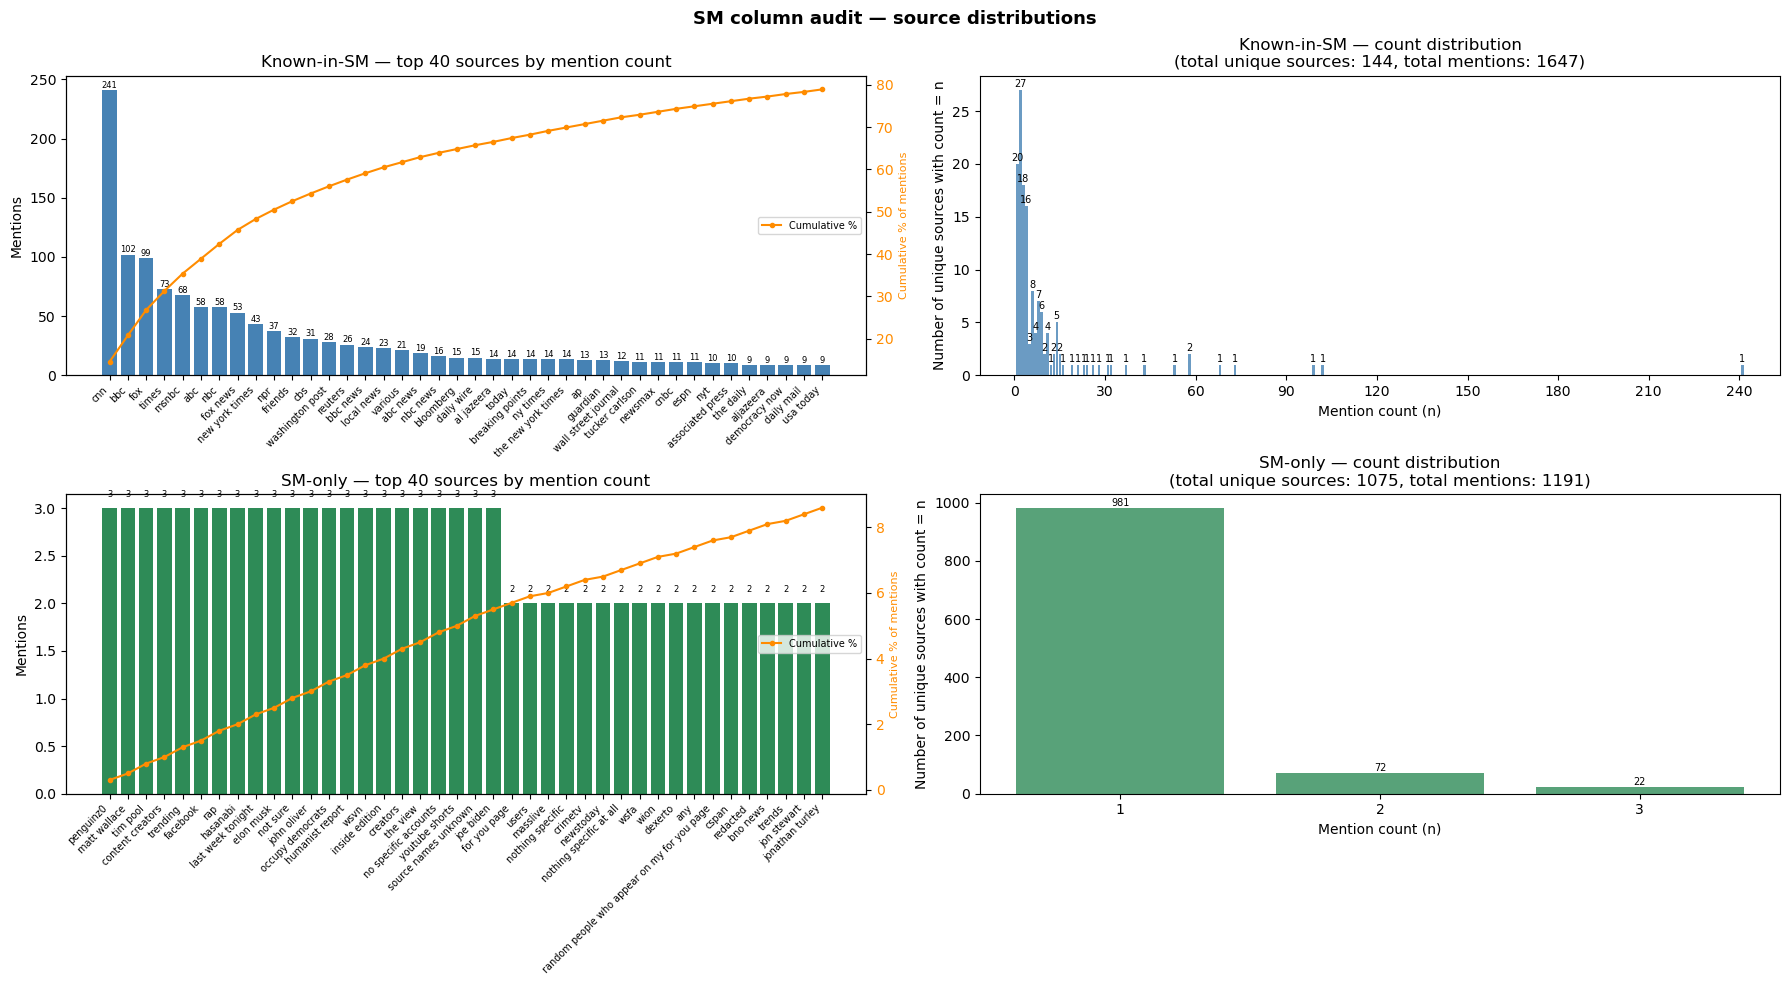

Known-in-SM:
  Unique sources: 144
  Total mentions: 1647
  Appear once:    20
  Appear 2-3x:    45
  Appear 4+:      79

SM-only:
  Unique sources: 1075
  Total mentions: 1191
  Appear once:    981
  Appear 2-3x:    94
  Appear 4+:      0



In [13]:
# Distribution charts for Known-in-SM and SM-only sources
# Left panel:  bar chart of top sources by mention count
# Right panel: mention-count distribution (how many sources have count=1, 2, 3, ...)
# Style matches the Step 3a chart

fig, axes = plt.subplots(2, 2, figsize=(18, 10))
fig.suptitle('SM column audit — source distributions', fontsize=13, fontweight='bold')

for row_idx, (df, label, colour) in enumerate([
    (known_in_sm,   'Known-in-SM',    'steelblue'),
    (sm_only, 'SM-only', 'seagreen'),
]):
    # ── left panel: top-N bar chart (up to 40 sources) ──────────────────────
    top_n = df.head(40).copy()
    ax_bar = axes[row_idx][0]
    bars = ax_bar.bar(range(len(top_n)), top_n['count'], color=colour)
    ax_bar.set_xticks(range(len(top_n)))
    ax_bar.set_xticklabels(top_n['source'], rotation=45, ha='right', fontsize=7)
    ax_bar.set_ylabel('Mentions')
    ax_bar.set_title(f'{label} — top {len(top_n)} sources by mention count')
    for bar, val in zip(bars, top_n['count']):
        ax_bar.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.1,
                    str(val), ha='center', va='bottom', fontsize=6)

    # cumulative % line on twin axis
    total = df['count'].sum()
    top_n['cumulative_pct'] = (top_n['count'].cumsum() / total * 100).round(1)
    ax2 = ax_bar.twinx()
    ax2.plot(range(len(top_n)), top_n['cumulative_pct'],
             color='darkorange', marker='o', markersize=3, linewidth=1.5,
             label='Cumulative %')
    ax2.set_ylabel('Cumulative % of mentions', color='darkorange', fontsize=8)
    ax2.tick_params(axis='y', labelcolor='darkorange')
    ax2.legend(loc='center right', fontsize=7)

    # ── right panel: distribution of counts (long-tail view) ────────────────
    ax_dist = axes[row_idx][1]
    count_dist = df['count'].value_counts().sort_index()
    ax_dist.bar(count_dist.index, count_dist.values, color=colour, alpha=0.8)
    ax_dist.set_xlabel('Mention count (n)')
    ax_dist.set_ylabel('Number of unique sources with count = n')
    ax_dist.set_title(f'{label} — count distribution\n'
                      f'(total unique sources: {len(df)}, total mentions: {total})')
    ax_dist.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
    for x, y in zip(count_dist.index, count_dist.values):
        ax_dist.text(x, y + 0.1, str(y), ha='center', va='bottom', fontsize=7)

plt.tight_layout()
plt.savefig('sm_audit_distributions.png', dpi=150)
plt.show()

# Summary stats
for df, label in [(known_in_sm, 'Known-in-SM'), (sm_only, 'SM-only')]:
    total = df['count'].sum()
    print(f"{label}:")
    print(f"  Unique sources: {len(df)}")
    print(f"  Total mentions: {total}")
    print(f"  Appear once:    {(df['count'] == 1).sum()}")
    print(f"  Appear 2-3x:    {df['count'].between(2, 3).sum()}")
    print(f"  Appear 4+:      {(df['count'] > 3).sum()}")
    print()


# Step 6: Unification — applied to ALL sources

All hardcoded dictionaries and normalisation rules live here and are applied to every source in the dataset,
regardless of whether it came from an MM or SM survey column.

The `unify()` function runs four operations in sequence:
1. **Platform-prefix strip** — removes 'youtube - ', 'tiktok: ', etc. from the start of a string
2. **Noise filter** — replaces generic/junk strings with `'NOISE'` (excluded from final table)
3. **Spacing normalisation** — collapses double spaces, strips leading @/#, hyphen → space
4. **Alias map** — maps all known variant spellings to one standard source name (MM and SM entries together)


In [14]:
# Fires when a known platform word is at the very start followed by a separator
# e.g. 'youtube - penguinz0' → 'penguinz0', 'tiktok: beau of the fifth column' → 'beau of the fifth column'
PLATFORM_PREFIXES = r'^(?:youtube|tiktok|instagram|ig|facebook|fb|twitter|x|reddit|snapchat)\s*[-:./]\s*'

# Strings that are clearly not source names — applied to ALL columns
NOISE_EXACT = {
    'n/a', 'na', 'n', 'a', 'no', 'none', 'nothing', 'not sure',
    'various', 'many', 'other', 'others', 'posts', 'ads', 'them',
    'users', 'content', 'creators', 'trending', 'explore page',
    'news feed', 'for you page', 'my feed', 'impact',
    'no specific sources', 'no specific accounts', 'not specific',
    'nothing specific', 'nothing specific at all', 'source names unknown',
    'independent journalists', 'random people', 'forum links',
    'advertisements', 'just following links from elsewhere',
    'only what shows up in my feed', 'i just read my feed',
    'random people who appear on my for you page',
    'rap', 'democrats', 'newstoday', 'america news',
    # bare generic words that appear as extraction artefacts
    'times', 'news', 'post', 'daily', 'report', 'review', 'online',
    'media', 'channel', 'network', 'radio', 'tv', 'web',
}

NOISE_PATTERNS = [
    r'^\d+$',                           # pure number
    r'^[a-z]$',                          # single letter
    r'\bjust\s+follow',
    r'\bonly\s+what\s+shows',
    r'\brandom\s+people\b',
    r'\bfor\s+you\s+page\b',
    r'\bmy\s+feed\b',
    r'\bnews\s+feed\b',
    r'\bno\s+specific\b',
    r'\bnothing\s+specific\b',
    r'\bsource\s+names\s+unknown\b',
]

# Order matters: more specific patterns come first.
# \b = word boundary — \bcnn\b matches 'cnn' but not 'xcnn'
ALIAS_MAP = [
        (r'\bfox\s*1[0-9]\b',                   'Fox 13'),
    (r'\bgoogle\s+discover\b',               'Google Discover'),

        # 'times' alone is NOT matched — too ambiguous (Financial Times, LA Times, etc.)
    (r'\bthe\s+new\s+york\s+times?\b',     'New York Times'),
    (r'\bnew\s+york\s+times?\b',            'New York Times'),
    (r'\bnytimes?\b',                         'New York Times'),
    (r'\bny\s+times?\b',                     'New York Times'),
    (r'\bnyt\b',                              'New York Times'),

        (r'\bcnn\s*news?\b',                     'CNN'),
    (r'\bcnn\b',                              'CNN'),

        (r'\bsky\s*news\b',                      'Sky News'),
    (r'\bskynews\b',                          'Sky News'),

        (r'\bfox\s+news\b',                      'Fox News'),
    (r'\bfoxnews\b',                          'Fox News'),
    (r'\blivenow\s+from\s+fox\b',           'Fox News'),
    (r'\bfox\b(?!\s*\d)',                   'Fox News'),

        (r'\bbbcnews\b',                          'BBC News'),
    (r'\bbbc\s+world\s+news\b',             'BBC News'),
    (r'\bbbc\s+world\b',                     'BBC News'),
    (r'\bbbc(?:\s+news)?\b',                 'BBC News'),

        (r'\bthe\s+washington\s+post\b',        'Washington Post'),
    (r'\bwashington\s+post\b',               'Washington Post'),
    (r'\bwapo\b',                             'Washington Post'),
    (r'\bwashpost\b',                         'Washington Post'),
    (r'\bwashingtonpost\b',                   'Washington Post'),
    (r'\btwp\b',                              'Washington Post'),

        (r'\bmsnbc\b',                            'MSNBC'),

        (r'\bnbc\s+nightly\s+news\b',           'NBC News'),
    (r'\bnbc\s+washington\b',                'NBC News'),
    (r'\bnbc(?:\s+news)?\b',                 'NBC News'),

        (r'\babc\s+world\s+news\b',             'ABC News'),
    (r'\bgood\s+morning\s+america\b',       'ABC News'),
    (r'\babc\s*\d+\s*(?:news)?\b',         'ABC News'),
    (r'\babc(?:\s+news)?\b',                 'ABC News'),

        (r'\bcbs\s+evening\s+news\b',           'CBS News'),
    (r'\b60\s+minutes\b',                    'CBS News'),
    (r'\bcbs(?:\s+news)?\b',                 'CBS News'),

        (r'\bnpr\b',                              'NPR'),
    (r'\bnational\s+public\s+radio\b',      'NPR'),

        (r'\bpbs(?:\s+news(?:hour)?)?\b',        'PBS NewsHour'),

        (r'\bassociated\s+press\b',              'Associated Press'),
    (r'\bapnews\b',                           'Associated Press'),
    (r'\bap\s+news\b',                       'Associated Press'),
    (r'\bap\b',                               'Associated Press'),

        (r'\breuters\b',                          'Reuters'),

        (r'\bthe\s+wall\s+street\s+journal\b', 'Wall Street Journal'),
    (r'\bwall\s+street\s+journal\b',        'Wall Street Journal'),
    (r'\bwallstreet\s+journal\b',            'Wall Street Journal'),
    (r'\bwsj\b',                              'Wall Street Journal'),

        (r'\bal\s+jazeera\b',                    'Al Jazeera'),
    (r'\baljazeera\b',                        'Al Jazeera'),

        (r'\byahoo(?:\s+news)?\b',               'Yahoo News'),
    (r'\bgoogle(?:\s+news)?\b',              'Google News'),
    (r'\bapple\s+news\b',                    'Apple News'),
    (r'\bmsn\b',                              'MSN News'),
    (r'\bflipboard\b',                        'Flipboard'),
    (r'\bground\.news\b',                    'Ground News'),
    (r'\bground\s+news\b',                   'Ground News'),
    (r'\bnews\s*break\b',                    'NewsBreak'),
    (r'\b1440\b',                             '1440 Daily Digest'),

        (r'\batlanta\s+journal[\s\-]+constitution\b', 'Atlanta Journal-Constitution'),
    (r'\batlanta\s+journal\b',               'Atlanta Journal-Constitution'),
    (r'\bajc\b',                              'Atlanta Journal-Constitution'),

        (r'\bfacebook\s+news\b',                 'Facebook'),   # FB news tab = FB platform
    (r'\bfacebook\b',                         'Facebook'),
    (r'\bfb\b',                               'Facebook'),
    (r'\binstagram\b',                        'Instagram'),
    (r'\big\b(?!n)',                          'Instagram'),
    (r'\btiktok\b',                           'TikTok'),
    (r'\btwitter\b',                          'Twitter/X'),
    (r'\bx\.com\b',                          'Twitter/X'),
    (r'\byoutube\s+shorts\b',                'YouTube'),
    (r'\byoutube\b',                          'YouTube'),
    (r'\byt\b',                               'YouTube'),
    (r'\breddit\b',                           'Reddit'),
    (r'\bsnapchat\b',                         'Snapchat'),
    (r'\bdiscord\b',                          'Discord'),
    (r'\bpinterest\b',                        'Pinterest'),
    (r'\blinkedin\b',                         'LinkedIn'),
    (r'\bthreads\b',                          'Threads'),
    (r'\bbluesky\b',                          'Bluesky'),
    (r'\bmastodon\b',                         'Mastodon'),
    (r'\btwitch\b',                           'Twitch'),

        (r'\busa\s+today\b',                     'USA Today'),
    (r'\bla\s+times\b',                      'Los Angeles Times'),
    (r'\blos\s+angeles\s+times\b',          'Los Angeles Times'),
    (r'\blatimes\b',                          'Los Angeles Times'),
    (r'\bboston\s+globe\b',                  'Boston Globe'),
    (r'\bnewsweek\b',                         'Newsweek'),
    (r'\btime\s+magazine\b',                 'TIME Magazine'),   # 'time' alone NOT matched
    (r'\bpolitico\b',                         'Politico'),
    (r'\bbloomberg\b',                        'Bloomberg'),
    (r'\bcnbc\b',                             'CNBC'),
    (r'\bforbes\b',                           'Forbes'),
    (r'\bthe\s+economist\b',                 'The Economist'),
    (r'\beconomist\b',                        'The Economist'),
    (r'\bfinancial\s+times\b',               'Financial Times'),
    (r'\bvox\b',                              'Vox'),
    (r'\bthe\s+atlantic\b',                  'The Atlantic'),
    (r'\batlantic\b',                         'The Atlantic'),
    (r'\bnew\s+yorker\b',                    'The New Yorker'),
    (r'\bthe\s+guardian\b',                  'The Guardian'),
    (r'\bguardian\b',                         'The Guardian'),
    (r'\btheguardian\b',                      'The Guardian'),
    (r'\baxios\b',                            'Axios'),
    (r'\bthe\s+hill\b',                      'The Hill'),
    (r'\bhuffpost\b',                         'HuffPost'),
    (r'\bhuffington\s+post\b',               'HuffPost'),
    (r'\bbuzzfeed\b',                         'BuzzFeed'),
    (r'\bespn\b',                             'ESPN'),
    (r'\bbreitbart\b',                        'Breitbart'),
    (r'\bthe\s+daily\s+wire\b',             'Daily Wire'),
    (r'\bdaily\s+wire\b',                    'Daily Wire'),
    (r'\bthe\s+blaze\b',                     'The Blaze'),
    (r'\bdaily\s+mail\b',                    'Daily Mail'),
    (r'\bnypost\b',                           'New York Post'),
    (r'\bnew\s+york\s+post\b',              'New York Post'),
    (r'\bny\s+post\b',                       'New York Post'),
    (r'\bnewsmax\b',                          'Newsmax'),
    (r'\bnewsnation\b',                       'NewsNation'),
    (r'\bdw\b',                               'DW (Deutsche Welle)'),
    (r'\bdeutsche\s+welle\b',                'DW (Deutsche Welle)'),
    (r'\bpropublica\b',                       'ProPublica'),
    (r'\btmz\b',                              'TMZ'),
    (r'\bslate\b',                            'Slate'),
    (r'\bvice\b',                             'Vice'),
    (r'\bsalon\b',                            'Salon'),
    (r'\bzerohedge\b',                        'ZeroHedge'),
    (r'\bmarketwatch\b',                      'MarketWatch'),
    (r'\btelemundo\b',                        'Telemundo'),
    (r'\bunivision\b',                        'Univision'),
    (r'\bcbc\b',                              'CBC'),
    (r'\bc-?span\b',                          'C-SPAN'),
    (r'\bdrudge\s*report\b',                 'Drudge Report'),
    (r'\breal\s+clear\s+politics\b',        'RealClearPolitics'),
    (r'\bpolitifact\b',                       'PolitiFact'),
    (r'\bsnopes\b',                           'Snopes'),
    (r'\bgreenbrier\s+news\b',               'Greenbrier News'),
    (r'\bwion\b',                             'WION'),
    (r'\bbn[o0]\s+news\b',                   'BNO News'),
    (r'\bbarstool(?:\s+sports)?\b',          'Barstool Sports'),
    (r'\bhollywood\s+unlocked\b',            'Hollywood Unlocked'),
    (r'\bthe\s+shade\s+room\b',             'The Shade Room'),
    (r'\bshade\s+room\b',                    'The Shade Room'),
    (r'\binside\s+edition\b',                'Inside Edition'),
    (r'\bmeidas\s*touch\b',                  'MeidasTouch'),
    (r'\boccupy\s+democrats\b',              'Occupy Democrats'),
    (r'\bthe\s+athletic\b',                  'The Athletic'),
    (r'\bathletic\b',                         'The Athletic'),
    (r'\btmz\b',                              'TMZ'),

        (r'\bthe\s+daily\s+show\b',             'The Daily Show'),
    (r'\bdaily\s+show\b',                    'The Daily Show'),
    (r'\bthe\s+view\b',                      'The View'),
    (r'\bjohn\s+oliver\b',                   'John Oliver'),
    (r'\blast\s+week\s+tonight\b',          'John Oliver'),
    (r'\bjon\s+stewart\b',                   'Jon Stewart'),
    (r'\bjohn\s+stewart\b',                  'Jon Stewart'),
    (r'\bseth\s+mey[oe]rs?\b',               'Seth Meyers'),
    (r'\bsome\s+more\s+news\b',             'Some More News'),
    (r'\bunder\s*the\s*desk\s*news\b',     'Under the Desk News'),
    (r'\bunderthedesknews\b',                 'Under the Desk News'),

        (r'\bbreaking\s+points\b',               'Breaking Points'),
    (r'\bdemocracy\s+now\b',                 'Democracy Now'),
    (r'\bpod\s+save\s+america\b',           'Pod Save America'),

        (r'\bthe\s+young\s+turks\b',            'TYT'),
    (r'\byoung\s+turks\b',                   'TYT'),
    (r'\btyt\b',                              'TYT'),
    (r'\bhasanabi\b',                         'Hasanabi'),
    (r'\bhasan\s+piker\b',                   'Hasanabi'),
    (r'\bpenguinz0\b',                        'Penguinz0'),
    (r'\bmoist\s*cr1tikal\b',                'Penguinz0'),
    (r'\btim\s+pool\b',                      'Tim Pool'),
    (r'\btimcast\b',                          'Tim Pool'),
    (r'\bmark\s+dice\b',                     'Mark Dice'),
    (r'\bandy\s+ngo\b',                      'Andy Ngo'),
    (r'\bmatt\s+walsh\b',                    'Matt Walsh'),
    (r'\bmatt\s+wallace\b',                  'Matt Wallace'),
    (r'\belon\s+musk\b',                     'Elon Musk'),
    (r'\belonmusk\b',                         'Elon Musk'),
    (r'\bjordan\s+peterson\b',               'Jordan Peterson'),
    (r'\bgeorge\s+conway\b',                 'George Conway'),
    (r'\bglenn?\s+greenwald\b',              'Glenn Greenwald'),
    (r'\bjonathan\s+turley\b',               'Jonathan Turley'),
    (r'\bbeau\s+of\s+the\s+fifth\s+column\b', 'Beau of the Fifth Column'),
    (r'\bmajority\s+report\b',               'Majority Report'),
    (r'\bsecular\s+talk\b',                  'Secular Talk'),
    (r'\bbrian\s+tyler\s+cohen\b',          'Brian Tyler Cohen'),
    (r'\bthe\s+rational\s+national\b',      'The Rational National'),
    (r'\brational\s+national\b',             'The Rational National'),
    (r'\bthe\s+humanist\s+report\b',        'Humanist Report'),
    (r'\bhumanist\s+report\b',               'Humanist Report'),
    (r'\bzero\s+hedge\b',                    'ZeroHedge'),
    (r'\bred[a]cted\b',                       'Redacted'),

        (r'\bnew\s*york\s*tomes?\b',            'New York Times'),   # typo 'Tomes'
    (r'\bnewyorktimes?\b',                    'New York Times'),
    (r'\bwallstreetjournal\b',                'Wall Street Journal'),
    (r'\busatoday\b',                         'USA Today'),
    (r'\bnbcnews\b',                          'NBC News'),
    (r'\bcbsnews\b',                          'CBS News'),
    (r'\babcnews\b',                          'ABC News'),
    (r'\bhuff\s+post\b',                     'HuffPost'),
    (r'\bdailymail\b',                        'Daily Mail'),
    (r'\bdailymirror\b',                      'Daily Mirror'),
    (r'\bpropublica\b',                       'ProPublica'),
    (r'\bpro\s+publica\b',                   'ProPublica'),
    (r'\bnytimes?\b',                         'New York Times'),
    (r'\bwapo\b',                             'Washington Post'),
    (r'\bwashpost\b',                         'Washington Post'),
    (r'\bpod\s+saves?\s+america\b',         'Pod Save America'),  # typo 'saves'
    (r'\bnews\s*nation\b',                   'NewsNation'),
    (r'\bspectrum\s+news\b',                 'Spectrum News'),
    (r'\bblazetv\b',                          'BlazeTV'),
    (r'\bthe\s+blaze\b',                     'The Blaze'),
    (r'\bblaze\s+tv\b',                      'BlazeTV'),
    (r'\bepoch\s+times\b',                   'Epoch Times'),
    (r'\bnational\s+review\b',               'National Review'),
    (r'\bthe\s+intercept\b',                 'The Intercept'),
    (r'\bintercept\b',                        'The Intercept'),
    (r'\bjacobins?\b',                        'Jacobin'),
    (r'\bthe\s+bulwark\b',                   'The Bulwark'),
    (r'\bbulwark\b',                          'The Bulwark'),
    (r'\bbusiness\s+insider\b',              'Business Insider'),
    (r'\bjJerusalem\s+post\b',               'Jerusalem Post'),
    (r'\bjPost\b',                            'Jerusalem Post'),
    (r'\btimes\s+of\s+israel\b',            'Times Of Israel'),
    (r'\bchicago\s+tribune\b',               'Chicago Tribune'),
    (r'\bhouston\s+chronicle\b',             'Houston Chronicle'),
    (r'\bdetroit\s+free\s+press\b',         'Detroit Free Press'),
    (r'\bstar\s+tribune\b',                  'Star Tribune'),
    (r'\bpalm\s+beach\s+post\b',            'Palm Beach Post'),
    (r'\bflorida\s+today\b',                 'Florida Today'),
    (r'\bnewsday\b',                          'Newsday'),
    (r'\bpenn\s*live\b',                     'PennLive'),
    (r'\bmasslive\b',                         'MassLive'),
    (r'\bthe\s+telegraph\b',                 'The Telegraph'),
    (r'\btelegraph\b',                        'The Telegraph'),
    (r'\bmiddle\s+east\s+eye\b',            'Middle East Eye'),
    (r'\bvoa\b',                              'Voice of America'),
    (r'\bvoice\s+of\s+america\b',           'Voice of America'),
    (r'\bnpr\s+news\b',                      'NPR'),
    (r'\bup\s+first\b',                      'NPR'),           # NPR daily podcast
    (r'\bmorning\s+edition\b',               'NPR'),           # NPR morning programme
    (r'\ball\s+things\s+considered\b',      'NPR'),           # NPR afternoon programme
    (r'\bmarketplace\b',                      'NPR'),           # NPR business programme
    (r'\bthis\s+american\s+life\b',         'This American Life'),
    (r'\bsirius\s*xm\b',                     'SiriusXM'),
    (r'\bspotify\b',                          'Spotify'),
    (r'\bhaystack\b',                         'Haystack News'),
    (r'\bsmartNews\b',                        'SmartNews'),
    (r'\bsmart\s*news\s+app\b',             'SmartNews'),
    (r'\bbing\b',                             'Bing News'),
    (r'\bdrudge\b(?!\s*report)',             'Drudge Report'),
        (r'\bjoe\s+rogan\s+experience\b',       'Joe Rogan'),
    (r'\bjoe\s+rogan\b',                     'Joe Rogan'),
    (r'\btimcastirl\b',                       'Tim Pool'),
    (r'\btucker\s+carlson\b',                'Tucker Carlson'),
    (r'\btucker\b(?!\s+carlson)',            'Tucker Carlson'),
    (r'\bben\s+shapiro\b',                   'Ben Shapiro'),
    (r'\brachel\s+maddow\b',                 'Rachel Maddow'),
    (r'\bmegyn?\s+kell?ey?\b',              'Megyn Kelly'),   # Megan Kelly / Megyn Kelly
    (r'\bmegan\s+kell?ey?\b',               'Megyn Kelly'),
    (r'\banderson\s+cooper\b',               'Anderson Cooper'),
    (r'\bdan\s+bongino\b',                   'Dan Bongino'),
    (r'\bdavid\s+pakman\b',                  'David Pakman'),
    (r'\bdpakman\b',                          'David Pakman'),
    (r'\bphilip\s+de\s*franco\b',           'Philip DeFranco'),
    (r'\bphilip\s+di\s*franco\b',           'Philip DeFranco'),
    (r'\bphil\s+de\s*franco\b',             'Philip DeFranco'),
    (r'\bphilip\s+defranco\b',               'Philip DeFranco'),
    (r'\bphilp\s+defranco\b',                'Philip DeFranco'),
    (r'\bphilipp?\s*defranco\b',             'Philip DeFranco'),
    (r'\bpdefranco\b',                        'Philip DeFranco'),
    (r'\bphil\s+defranco\b',                 'Philip DeFranco'),
    (r'\bbrian\s+tay(?:lor|ler)\s+cohen\b', 'Brian Tyler Cohen'),  # typo 'taylor'
    (r'\bjack\s+posobiec\b',                 'Jack Posobiec'),
    (r'\bcharlie\s+kirk\b',                  'Charlie Kirk'),
    (r'\bmichael\s+knowles\b',               'Michael Knowles'),
    (r'\bmark\s+levin\b',                    'Mark Levin'),
    (r'\bglenn\s+beck\b',                    'Glenn Beck'),
    (r'\brussell\s+brand\b',                 'Russell Brand'),
    (r'\brusselbrand\b',                      'Russell Brand'),
    (r'\bcandace\s+owens\b',                 'Candace Owens'),
    (r'\bcandice\s+owens\b',                 'Candace Owens'),
    (r'\bchris\s+hayes\b',                   'Chris Hayes'),
    (r'\bari\s+melber\b',                    'Ari Melber'),
    (r'\blawrence\s+o.?donnell\b',           "Lawrence O'Donnell"),
    (r'\bjimmy\s+dore\b',                    'Jimmy Dore'),
    (r'\bsam\s+seder\b',                     'Sam Seder'),
    (r'\bdylan\s+page\b',                    'Dylan Page'),
    (r'\bdylan\.page\b',                     'Dylan Page'),
    (r'\bmorning\s+joe\b',                   'Morning Joe'),
    (r'\bh3\s+podcast\b',                    'H3 Podcast'),
    (r'\bpbd\s+podcast\b',                   'PBD Podcast'),
    (r'\bstephen\s+colbert\b',               'Stephen Colbert'),
    (r'\bcolbert\b',                          'Stephen Colbert'),
    (r'\bnick\s+jackson\b',                  'Nick Jackson'),
    (r'\bthe\s+five\b',                      'The Five'),        # Fox News programme
    (r'\bmeet\s+the\s+press\b',             'Meet The Press'),  # NBC programme
    (r'\bthe\s+ringer\b',                    'The Ringer'),
        (r'\bwbal\b',                             'WBAL'),
    (r'\bwbbm\b',                             'WBBM'),
    (r'\bwfla\b',                             'WFLA'),
    (r'\bwfmz\b',                             'WFMZ'),
    (r'\bwgal\b',                             'WGAL'),
    (r'\bwsvn\b',                             'WSVN'),
    (r'\bwsfa\b',                             'WSFA'),
    (r'\bwsbtv\b',                            'WSB-TV'),
    (r'\bwplg\b',                             'WPLG'),
    (r'\bkcci\b',                             'KCCI'),
    (r'\bkake\b',                             'KAKE'),
    (r'\bkfyr\b',                             'KFYR'),
    (r'\bkcrg\b',                             'KCRG'),
    (r'\bkfvs\b',                             'KFVS'),
    (r'\bktla\b(?!\s*5)',                    'KTLA'),
    (r'\bktla\s*5\b',                        'KTLA'),
    (r'\bksl\b',                              'KSL'),
    (r'\bkare\s*11\b',                       'KARE 11'),
    (r'\bwkbn\b',                             'WKBN'),
    (r'\bwavy\s*10\b',                       'WAVY-TV 10'),
    (r'\bwavy10\b',                           'WAVY-TV 10'),
    (r'\bwxpn\b',                             'WXPN'),
    (r'\bdc\s+news\s+now\b',                'DC News Now'),
    (r'\bnews\s+12\b',                       'News 12'),
    (r'\bnews\s+on\s+6\b',                  'News On 6'),
    (r'\bspectrum\s+news\b',                 'Spectrum News'),
        (r'\bnightly\s+news\b',                  'NBC News'),   # NBC Nightly News
    (r'\btoday\s+show\b',                    'Today Show'), # NBC Today Show
    (r'\btoday\b(?!\s+show)',                'Today Show'), # bare 'Today'
    (r'\bthe\s+daily\b(?!\s+show|\s+wire)', 'The Daily'), # NYT podcast

        (r'\bnew\s*york\s*tomes?\b',             'New York Times'),
    (r'\bnewyorktimes?\b',                   'New York Times'),
    (r'\bwallstreetjournal\b',               'Wall Street Journal'),
    (r'\bwallstreetjurnal\b',                'Wall Street Journal'),
    (r'\bwall\s+st\s+journal\b',             'Wall Street Journal'),
    (r'\bwall\s+st\.?\s+j\b',               'Wall Street Journal'),
    (r'\busatoday\b',                        'USA Today'),
    (r'\bnbcnews\b',                         'NBC News'),
    (r'\bcbsnews\b',                         'CBS News'),
    (r'\bcbsboston\b',                       'CBS News'),
    (r'\babcnews\b',                         'ABC News'),
    (r'\bhuff\s+post\b',                     'HuffPost'),
    (r'\bhuffnews\b',                        'HuffPost'),
    (r'\bhiffpost\b',                        'HuffPost'),
    (r'\bhiff\s+post\b',                     'HuffPost'),
    (r'\bhuffingto\.\s*post\b',              'HuffPost'),
    (r'\bhuffpo\b',                          'HuffPost'),
    (r'\bdailymail\b',                       'Daily Mail'),
    (r'\bdailymirror\b',                     'Daily Mirror'),
    (r'\bpro\s+publica\b',                   'ProPublica'),
    (r'\bassosciated\s+press\b',             'Associated Press'),
    (r'\brueters\b',                         'Reuters'),
    (r'\bpod\s+saves?\s+america\b',          'Pod Save America'),
    (r'\bnews\s*nation\b',                   'NewsNation'),
    (r'\bnsnbc\b',                           'MSNBC'),
    (r'\bmsmbc\b',                           'MSNBC'),
    (r'\bspectrum\s+news\b',                 'Spectrum News'),
    (r'\bblazetv\b',                         'BlazeTV'),
    (r'\bblaze\s+tv\b',                      'BlazeTV'),
    (r'\bepoch\s+times\b',                   'Epoch Times'),
    (r'\bnational\s+review\b',               'National Review'),
    (r'\bthe\s+intercept\b',                 'The Intercept'),
    (r'\bintercept\b',                       'The Intercept'),
    (r'\bjacobins?\b',                       'Jacobin'),
    (r'\bjacobian\b',                        'Jacobin'),
    (r'\bthe\s+bulwark\b',                   'The Bulwark'),
    (r'\bbusiness\s+insider\b',              'Business Insider'),
    (r'\binsider\b(?!\s+edition)',           'Business Insider'),
    (r'\bjerusalem\s+post\b',               'Jerusalem Post'),
    (r'\btimes\s+of\s+israel\b',             'Times Of Israel'),
    (r'\bynet\b',                            'Ynet'),
    (r'\bchicago\s+tribune\b',               'Chicago Tribune'),
    (r'\bhouston\s+chronicle\b',             'Houston Chronicle'),
    (r'\bdetroit\s+free\s+press\b',          'Detroit Free Press'),
    (r'\bstar\s+tribune\b',                  'Star Tribune'),
    (r'\bstart\s+tribune\b',                 'Star Tribune'),
    (r'\bstar\s+tribnue\b',                  'Star Tribune'),
    (r'\bpalm\s+beach\s+post\b',             'Palm Beach Post'),
    (r'\bflorida\s+today\b',                 'Florida Today'),
    (r'\bnewsday\b',                         'Newsday'),
    (r'\bpenn\s*live\b',                     'PennLive'),
    (r'\bmasslive\b',                        'MassLive'),
    (r'\bthe\s+telegraph\b',                 'The Telegraph'),
    (r'\btelegraph\b',                       'The Telegraph'),
    (r'\bmiddle\s+east\s+eye\b',             'Middle East Eye'),
    (r'\bmiddle\s+eastern\s+eye\b',          'Middle East Eye'),
    (r'\bvoa\b',                             'Voice of America'),
    (r'\bvoice\s+of\s+america\b',            'Voice of America'),
    (r'\bnpr\s+news\b',                      'NPR'),
    (r'\bup\s+first\b',                      'NPR'),
    (r'\bmorning\s+edition\b',               'NPR'),
    (r'\ball\s+things\s+considered\b',       'NPR'),
    (r'\bfresh\s+air\b',                     'NPR'),
    (r'\bmarketplace\b',                     'NPR'),
    (r'\bthis\s+american\s+life\b',          'This American Life'),
    (r'\bsirius\s*xm\b',                     'SiriusXM'),
    (r'\bxm\s+radio\b',                      'SiriusXM'),
    (r'\biheart\s*radio\b',                  'iHeartRadio'),
    (r'\bspotify\b',                         'Spotify'),
    (r'\bhaystack\b',                        'Haystack News'),
    (r'\bsmart\s*news\b',                    'SmartNews'),
    (r'\bbing\b(?!\s+news)',                 'Bing News'),
    (r'\bdrudge\b(?!\s*report)',             'Drudge Report'),
    (r'\bwashinton\s+post\b',                'Washington Post'),
    (r'\bwash\s+post\b',                     'Washington Post'),
    (r'\bwapost\b',                          'Washington Post'),
    (r'\bbcc\b',                             'BBC News'),      # typo for BBC
    (r'\bcnnbbc\b',                          'CNN'),           # combined → CNN first
    (r'\bcnncnn\b',                          'CNN'),
    (r'\bbloonberg\b',                       'Bloomberg'),
    (r'\bbloomburge\b',                      'Bloomberg'),
    (r'\bbloombergbusiness\b',               'Bloomberg'),
    (r'\bmarket\s+watch\b',                  'MarketWatch'),
    (r'\bbrietbart\b',                       'Breitbart'),
    (r'\bbreibart\b',                        'Breitbart'),
    (r'\bjoerogan\b',                        'Joe Rogan'),
    (r'\brogan\b(?!\s+experience)',          'Joe Rogan'),
    (r'\baj\s+english\b',                    'Al Jazeera'),
    (r'\bajenglish\b',                       'Al Jazeera'),
    (r'\baljazeeraenglish\b',                'Al Jazeera'),
    (r'\baljasera\b',                        'Al Jazeera'),
    (r'\baljazzira\b',                       'Al Jazeera'),
    (r'\bajazeera\b',                        'Al Jazeera'),
    (r'\bal-jazeera\b',                      'Al Jazeera'),
    (r'\baj\s+plus\b',                       'Al Jazeera'),
    (r'\bmedias?\s*touch\b',                 'MeidasTouch'),
    (r'\bmeidas\b(?!\s*touch)',              'MeidasTouch'),
    (r'\bmediastouch\b',                     'MeidasTouch'),
    (r'\bmidas\s+touch\s+network\b',         'MeidasTouch'),
    (r'\bthe\s+weather\s+channel\b',         'The Weather Channel'),
    (r'\bdaily\s+beast\b',                   'Daily Beast'),
    (r'\bpink\s+news\b',                     'PinkNews'),
    (r'\bnew\s+york\s+magazine\b',           'New York Magazine'),
    (r'\bnew\s+york\s+mag\b',               'New York Magazine'),
    (r'\boann?\b',                           'OAN'),
    (r'\boan\s+tv\b',                        'OAN'),
    (r'\boan\s+website\b',                   'OAN'),
    (r'\breal\s+americas?\s+voice\b',        'Real America\'s Voice'),
    (r'\bgateway\s+pundit\b',                'Gateway Pundit'),
    (r'\bthegatewaypundit\b',               'Gateway Pundit'),
    (r'\bthe\s+independent\b',               'The Independent'),
    (r'\bwashington\s+examiner\b',           'Washington Examiner'),
    (r'\bdenver\s+post\b',                   'Denver Post'),
    (r'\bboston\s+herald\b',                 'Boston Herald'),
    (r'\bkansas\s+city\s+star\b',            'Kansas City Star'),
    (r'\bsan\s+francisco\s+chronicle\b',     'San Francisco Chronicle'),
    (r'\barkansas\s+democrat\s*[-–]?\s*gazette\b', 'Arkansas Democrat-Gazette'),
    (r'\bgreen\s+bay\s+press\s*[-–]?\s*gazette\b', 'Green Bay Press-Gazette'),
    (r'\bjacksonville\s+daily\s+record\b',   'Jacksonville Daily Record'),
    (r'\bdallas\s+morning\s+news\b',         'Dallas Morning News'),
    (r'\borlando\s+sentinel\b',              'Orlando Sentinel'),
    (r'\bphiladelphia\s+inqui[re]+r?\b',     'Philadelphia Inquirer'),
    (r'\bsacramento\s+bee\b',               'Sacramento Bee'),
    (r'\bsacbee\b',                          'Sacramento Bee'),
    (r'\bsan\s+diego\s+union\s*[-–]?\s*tribune\b', 'San Diego Union-Tribune'),
    (r'\blas\s+vegas\s+review\s*[-–]?\s*journal\b', 'Las Vegas Review-Journal'),
    (r'\bcolorado\s+springs\s+gazette\b',    'Colorado Springs Gazette'),
    (r'\bomaha\s+world\s*[-–]?\s*herald\b',  'Omaha World-Herald'),
    (r'\bcolumbus\s+dispatch\b',             'Columbus Dispatch'),
    (r'\bcincinnati\s+enquirer\b',           'Cincinnati Enquirer'),
    (r'\bthe\s+providence\s+journal\b',      'Providence Journal'),
    (r'\bthe\s+oregonian\b',                 'The Oregonian'),
    (r'\bthe\s+charlotte\s+observer\b',      'Charlotte Observer'),
    (r'\bbuffalo\s+news\b',                  'Buffalo News'),
    (r'\btampa\s+bay\s+times\b',             'Tampa Bay Times'),
    (r'\btampabaytimes\b',                   'Tampa Bay Times'),
    (r'\bindianapolis\s+star\b',             'Indianapolis Star'),
    (r'\bindy\s+star\b',                     'Indianapolis Star'),
    (r'\blas\s+vegas\s+sun\b',              'Las Vegas Sun'),
    (r'\btexas\s+tribune\b',                 'Texas Tribune'),
    (r'\bhannity\b',                         'Sean Hannity'),
    (r'\bsean\s+hannity\b',                  'Sean Hannity'),
    (r'\bthe\s+sean\s+hannity\s+show\b',     'Sean Hannity'),
    (r'\blaura\s+ingraham\b',                'Laura Ingraham'),
    (r'\bthe\s+ingraham\s+angle\b',          'Laura Ingraham'),
    (r'\bjesse\s+wat?ers?\b',                'Jesse Watters'),
    (r'\bjesse\s+watters\s+primetime\b',     'Jesse Watters'),
    (r'\bgutfeld\b',                         'Gutfeld!'),
    (r'\bkudlow\b',                          'Kudlow'),
    (r'\bjimmy\s+kimmel\b',                  'Jimmy Kimmel'),
    (r'\bkimmel\b',                          'Jimmy Kimmel'),
    (r'\bbill\s+maher\b',                    'Bill Maher'),
    (r'\breal\s+time\s*[-–]?\s*bill\s+maher\b', 'Bill Maher'),
    (r'\bunder\s+the\s+news\s+desk\b',       'Under the Desk News'),
    (r'\bnews\s+under\s+the\s+desk\b',       'Under the Desk News'),
    (r'\bunder\s+the\s+desk\b(?!\s+news)',   'Under the Desk News'),
    (r'\blastweektonight\b',                 'John Oliver'),
    (r'\bthis\s+week\s+tonight\b',           'John Oliver'),
    (r'\blate\s+night\s+with\s+seth\b',      'Seth Meyers'),
    (r'\blate\s+night\s+with\s+jon\s+stewart\b', 'Jon Stewart'),
    (r'\bgoogles?\s+homepage\b',             'Google News'),
    (r'\bgoogles?\s+recommendations?\b',     'Google News'),
    (r'\bjust\s+googles?\s+recommendations?\b', 'Google News'),
    (r'\bnews\s+aggregate\b',                'News Aggregator'),
    (r'\bnews\s+aggregator\b',               'News Aggregator'),
    (r'\bdan\s+borg?ino\b',                  'Dan Bongino'),
    (r'\bbongino\b',                         'Dan Bongino'),
    (r'\bmegyn?\s+kell?e?y?\s+show\b',       'Megyn Kelly'),
    (r'\bmegyn?\s+kell?e?y?\b',             'Megyn Kelly'),
    (r'\bmegan\s+kell?e?y?\b',              'Megyn Kelly'),
    (r'\bphillip\s+defranco\b',              'Philip DeFranco'),
    (r'\bphillipdefranco\b',                 'Philip DeFranco'),
    (r'\bphilip\s+difranco\b',              'Philip DeFranco'),
    (r'\bphilp\s+defranco\b',               'Philip DeFranco'),
    (r'\bpdefranco\b',                       'Philip DeFranco'),
    (r'\bbrian\s+tay(?:lor|ler)\s+cohen\b',  'Brian Tyler Cohen'),
    (r'\bphilip\s+lewis\b',                  'Philip Lewis'),
    (r'\bjack\s+posi?beic?\b',               'Jack Posobiec'),
    (r'\bpatreon\b',                         'Substack'),
    (r'\bsubstack\b',                        'Substack'),
    (r'\bnbc4\b',                            'NBC News'),
    (r'\bnbc\s*4\b',                         'NBC News'),
    (r'\bworld\s+news\s+tonight\b',          'ABC News'),
    (r'\bnightly\s+news\b',                  'NBC News'),
    (r'\btoday\s+show\b',                    'Today Show'),
    (r'\btoday\b(?!\s+show)',                'Today Show'),
    (r'\bdateline\b',                        'Dateline NBC'),
    (r'\bfrontline\b',                       'Frontline'),
    (r'\bface\s+the\s+nation\b',             'CBS News'),
    (r'\bthe\s+daily\b(?!\s+show|\s+wire)',  'The Daily'),
    (r'\bmorning\s+wire\b',                  'Morning Wire'),
    (r'\bpolitical\s+wire\b',                'Political Wire'),
        (r'\bwcco\b',    'WCCO'), (r'\bwesh\b',    'WESH'), (r'\bwdrb\b',    'WDRB'),
    (r'\bwafb\b',    'WAFB'), (r'\bkcal\b',    'KCAL'), (r'\bpix11\b',   'PIX11'),
    (r'\bwave\s*3\b','WAVE 3'),(r'\bwlky\b',   'WLKY'), (r'\bkptvfox\b', 'KPTV'),
    (r'\bwtol\b',    'WTOL'), (r'\bwtol11\b',  'WTOL'), (r'\bwjhl\b',    'WJHL'),
    (r'\bwjz\b',     'WJZ'),  (r'\bwjbo\b',    'WJBO'), (r'\bwmar\b',    'WMAR'),
    (r'\bwbay\b',    'WBAY'), (r'\bwkbn\b',    'WKBN'), (r'\bwkrg\b',    'WKRG'),
    (r'\bwesh\b',    'WESH'), (r'\bwesh\s+5pm\b','WESH'),(r'\bwvlt\b',   'WVLT'),
    (r'\bwymt\b',    'WYMT'), (r'\bwtae\b',    'WTAE'), (r'\bwtaj\b',    'WTAJ'),
    (r'\bwish\b',    'WISH'), (r'\bwgrz\b',    'WGRZ'), (r'\bwgrc\b',    'WGRC'),
    (r'\bwgal\b',    'WGAL'), (r'\bwrko\b',    'WRKO'), (r'\bwdbo\b',    'WDBO'),
    (r'\bwnyc\b',    'WNYC'), (r'\bwnbc\b',    'WNBC'), (r'\bwnep\b',    'WNEP'),
    (r'\bwlbt\b',    'WLBT'), (r'\bwboc\b',    'WBOC'), (r'\bwbur\b',    'WBUR'),
    (r'\bwtnh\b',    'WTNH'), (r'\bwfsb\b',    'WFSB'), (r'\bwvla\b',    'WVLA'),
    (r'\bwbrz\b',    'WBRZ'), (r'\bwbrc\b',    'WBRC'), (r'\bwbkv\b',    'WBKV'),
    (r'\bwben\b',    'WBEN'), (r'\bwabc\b',    'WABC'), (r'\bwwj\b',     'WWJ'),
    (r'\bkoco\b',    'KOCO'), (r'\bkoco\b',    'KOCO'), (r'\bkgw\b',     'KGW'),
    (r'\bkiro\b',    'KIRO'), (r'\bking\s*tv\b','KING TV'),(r'\bkron\b',  'KRON'),
    (r'\bkhou\b',    'KHOU'), (r'\bkhou11\b',  'KHOU'), (r'\bkou11\b',   'KHOU'),
    (r'\bkatc\b',    'KATC'), (r'\bksat\b',    'KSAT'), (r'\bkens\b',    'KENS'),
    (r'\bkbtx\b',    'KBTX'), (r'\bktvz\b',    'KTVZ'), (r'\bktck\b',    'KTCK'),
    (r'\bkten\b',    'KTEN'), (r'\bkcra\b',    'KCRA'), (r'\bkstp\b',    'KSTP'),
    (r'\bkxan\b',    'KXAN'), (r'\bkwqc\b',    'KWQC'), (r'\bkwwl\b',    'KWWL'),
    (r'\bkrgv\b',    'KRGV'), (r'\bkdka\b',    'KDKA'), (r'\bkduc\b',    'KDUC'),
    (r'\bkstx\b',    'KSTX'), (r'\bwoai\b',    'WOAI'), (r'\bkotv\b',    'KOTV'),
    (r'\bktnv\b',    'KTNV'), (r'\bktla5\b',   'KTLA'), (r'\bktla5cw\b', 'KTLA'),
    (r'\bkslt\b',    'KSLT'), (r'\bksen\b',    'KSEN'), (r'\bkstv\b',    'KSTV'),
    (r'\brtv6\b',    'RTV6'), (r'\bwho13\b',   'WHO-TV'),(r'\bny1\b',    'NY1'),
    (r'\bnecn\b',    'NECN'), (r'\bwitn\b',    'WITN'), (r'\bwhnt\b',    'WHNT'),
    (r'\bwhio\b',    'WHIO'), (r'\bwhec\b',    'WHEC'), (r'\bwevh\b',    'WEVH'),
    (r'\bwesh\b',    'WESH'), (r'\bwesh5pm\b', 'WESH'), (r'\bwesh5\b',   'WESH'),
    (r'\bksen\b',    'KSEN'), (r'\bwthr\b',    'WTHR'), (r'\bwltx\b',    'WLTX'),
    (r'\bwlox\b',    'WLOX'), (r'\bwlns\b',    'WLNS'), (r'\bwlnk\b',    'WLNK'),
    (r'\bwkyc\b',    'WKYC'), (r'\bwkyt\b',    'WKYT'), (r'\bwkrn\b',    'WKRN'),
    (r'\bwtop\b',    'WTOP'), (r'\bwmal\b',    'WMAL'), (r'\bwwdc\b',    'WWDC'),
    (r'\bwson\b',    'WSON'), (r'\bwspa\b',    'WSPA'), (r'\bwspt\b',    'WSPT'),
    (r'\bwpro\b',    'WPRO'), (r'\bwpio\b',    'WPIO'), (r'\bwnsc\b',    'WNSC'),
    (r'\bwis\b(?!\s+news\s+10|\s*10)',         'WIS'),
    (r'\bwis\s+news\s+10\b',                   'WIS'),
    (r'\bwgn\b',     'WGN'),  (r'\bwgts\b',    'WGTS'), (r'\bwgau\b',    'WGAU'),
    (r'\bwvbo\b',    'WVBO'), (r'\bwogb\b',    'WOGB'), (r'\bwevh\b',    'WEVH'),
    (r'\bwjbo\b',    'WJBO'),
        (r'\bdem?ocracy\s*now!?\b',              'Democracy Now'),
    (r'\bwashington\s+examiner\b',           'Washington Examiner'),
    (r'\bnational\s+news\s+channels?\b',     'National TV News Channel'),
    (r'\blocal\s+television\s+news\b',       'Local News'),
    (r'\blocal\s+stations?\b',               'Local News'),
    (r'\blocal\s+new\s+stations?\b',         'Local News'),
    (r'\bnewspaper\b',                       'Print & Digital News Outlet'),
    (r'\bncb\s+news\b',                      'NBC News'),
    (r'\bnbc\s*news\b',                      'NBC News'),
    (r'\bworld\s+news\s+tonight\b',          'ABC News'),
    (r'\breuters?\b',                        'Reuters'),

        (r'\bupi\b',                             'UPI'),
    (r'\bunited\s+press\s+international\b',  'UPI'),
    (r'\bvariety\b',                         'Variety'),
    (r'\bny\s+daily\s+news\b',              'NY Daily News'),
    (r'\bnew\s+york\s+daily\s+news\b',      'NY Daily News'),
    (r'\bnydailynews\b',                     'NY Daily News'),
    (r'\bdaily\s+news\b(?!\s+cast)',         'Daily News'),
    (r'\bus\s+news\b',                       'US News'),
    (r'\busnews\b',                          'US News'),
    (r'\bthe\s+chronicle\s+of\s+higher\s+education\b', 'The Chronicle Of Higher Education'),
    (r'\bwavy\s+tv\s+10\b',                 'WAVY-TV 10'),   # duplicate spelling
    (r'\b13news\s*now\b',                    '13News Now'),   # duplicate 13newsnow
    (r'\bsan\s+antonio\s+express\s*[-–]?\s*news\b', 'San Antonio Express-News'),
    (r'\bmercury\s+news\b',                  'Mercury News'),
    (r'\bpensacola\s+news\s+journal\b',      'Pensacola News Journal'),
    (r'\bgrosse\s+pointe\s+news\b',          'Grosse Pointe News'),
    (r'\bwane\s+15\b',                       'WANE 15'),
    (r'\bhemet\s+valley\s+news\b',           'Hemet Valley News'),
    (r'\baction\s+news\s+jax\b',             'Action News Jax'),
    (r'\bknx\s+1070\b',                      'KNX 1070'),
    (r'\bknx\s+news\s+los\s+angeles\b',      'KNX 1070'),
    (r'\bnews\s*&\s*talk\s+840\b',           'News & Talk 840'),
    (r'\bwicr\b',                            'WICR'),
    (r'\bheadline\s+news\b',                 'Headline News'),
    (r'\bevening\s+broadcast\s+news\b',      'Headline News'),
    (r'\bany\s+of\s+the\s+network\s+news\b', 'Headline News'),

        (r'\basmongold\s*tv\b',                  'Asmongold'),
    (r'\basmondgoldtv\b',                    'Asmongold'),
    (r'\basmongold\b',                       'Asmongold'),
    (r'\bi24\s*news\b',                      'i24News'),
    (r'\barise\s*tv\b',                      'AriseTv'),
    (r'\bsouth\s+carolina\s+public\s+radio\b','South Carolina Public Radio'),
    (r'\bnevada\s+public\s+radio\b',         'Nevada Public Radio'),
    (r'\bwtmj\s*radio\b',                    'WTMJ Radio'),
    (r'\bradiolab\b',                        'Radiolab'),
    (r'\bralph\s+nader\s+radio\s+hour\b',    'Ralph Nader Radio Hour'),
    (r'\bairone\s+radio\b',                  'Airone Radio'),
    (r'\bhal\s+turner\s+radio\b',            'Hal Turner Radio'),
    (r'\brocanews\b',                        'Rocanews'),
    (r'\bglobal\s+news\b',                   'Global News'),
    (r'\bdisclose\.?tv\b',                   'Disclose.tv'),
    (r'\bthe\s+beverly\s+hills\s+courier\b', 'Beverly Hills Courier'),
    (r'\bbeverly\s+hills\s+courier\b',       'Beverly Hills Courier'),
    (r'\bthe\s+brunswick\s+news\b',          'The Brunswick News'),
    (r'\baction\s+news\s+jax\b',             'Action News Jax'),
    (r'\bnews4jax\b',                        'Action News Jax'),
    (r'\bgreat\s+falls\s+tribune\b',         'Great Falls Tribune'),
    (r'\bla\s+crosse\s+tribune\b',           'La Crosse Tribune'),
    (r'\bmuscatine\s+journal\b',             'Muscatine Journal'),
    (r'\bsarasota\s+herald\s*[-–]?\s*tribune\b', 'Sarasota Herald-Tribune'),
    (r'\bstatesman\s+journal\b',             'Statesman Journal'),
    (r'\bwapt\s+news\b',                     'WAPT News'),
    (r'\bwapt\s+morni[ng]+\s+news\b',        'WAPT News'),
    (r'\bwbkolocal\s+news\b',               'WBKO News'),
    (r'\bwbko\b',                            'WBKO News'),
    (r'\bmorning\s+joe\b',                   'Morning Joe'),
    (r'\bjoe\s+biden\b',                     'Joe Biden'),
    (r'\bbig\s+city\s+journal\b',            'Big City Journal'),
    (r'\bboston\s+globe\b',                  'Boston Globe'),

]
def unify(s):
    """
    Apply all cleaning/normalisation steps to a single source string, then alias-map it.
    Runs on ALL sources regardless of MM or SM column origin.
    Returns 'NOISE' for strings that are clearly not source names.
    """
    import re

    # Step A: strip platform prefix (e.g. 'youtube - penguinz0' → 'penguinz0')
    PLATFORM_PREFIXES = r'^(?:youtube|tiktok|instagram|ig|facebook|fb|twitter|x|reddit|snapchat)\s*[-:./]\s*'
    s = re.sub(PLATFORM_PREFIXES, '', s, flags=re.IGNORECASE).strip()

    s = re.sub(r'^[@#]', '', s)
    s = re.sub(r'\s+', ' ', s)
    s = s.strip()

    # Step C: noise filter
    if s in NOISE_EXACT:
        return 'NOISE'
    for pat in NOISE_PATTERNS:
        if re.search(pat, s):
            return 'NOISE'

    # Step D: alias map
    for pattern, standard_name in ALIAS_MAP:
        if re.search(pattern, s, re.IGNORECASE):
            return standard_name

    # Fallback: title-case the raw string
    return s.title()

unified_series = all_extracted_step4.apply(unify)

# Track which positions in all_extracted_step4 came from SM columns
# (needed for the 'National News Channel on Social Media' category in Step 8)
sm_col_indices = set(
    exploded[exploded['col_type'] == 'SM_col'].index.tolist()
)

# Exclude NOISE rows
unified_series_clean = unified_series[unified_series != 'NOISE'].reset_index(drop=True)

# Frequency table after unification
unified_freq = unified_series_clean.value_counts().reset_index()
unified_freq.columns = ['source', 'count']

noise_count = (unified_series == 'NOISE').sum()
unique_pre   = all_extracted_step4.nunique()
unique_post  = unified_series_clean.nunique()

print(f"Unique strings before Step 6: {unique_pre}")
print(f"Noise strings removed:        {noise_count}")
print(f"Unique strings after  Step 6: {unique_post}")
print(f"Reduced by: {unique_pre - unique_post} ({(unique_pre-unique_post)/unique_pre*100:.1f}%)")
print()
top_unified = unified_freq[unified_freq['count'] > 3].copy()
print(f"Sources with >3 mentions: {len(top_unified)}")
with pd.option_context('display.max_rows', 300, 'display.max_colwidth', 60):
    print(top_unified.to_string())


KeyboardInterrupt: 

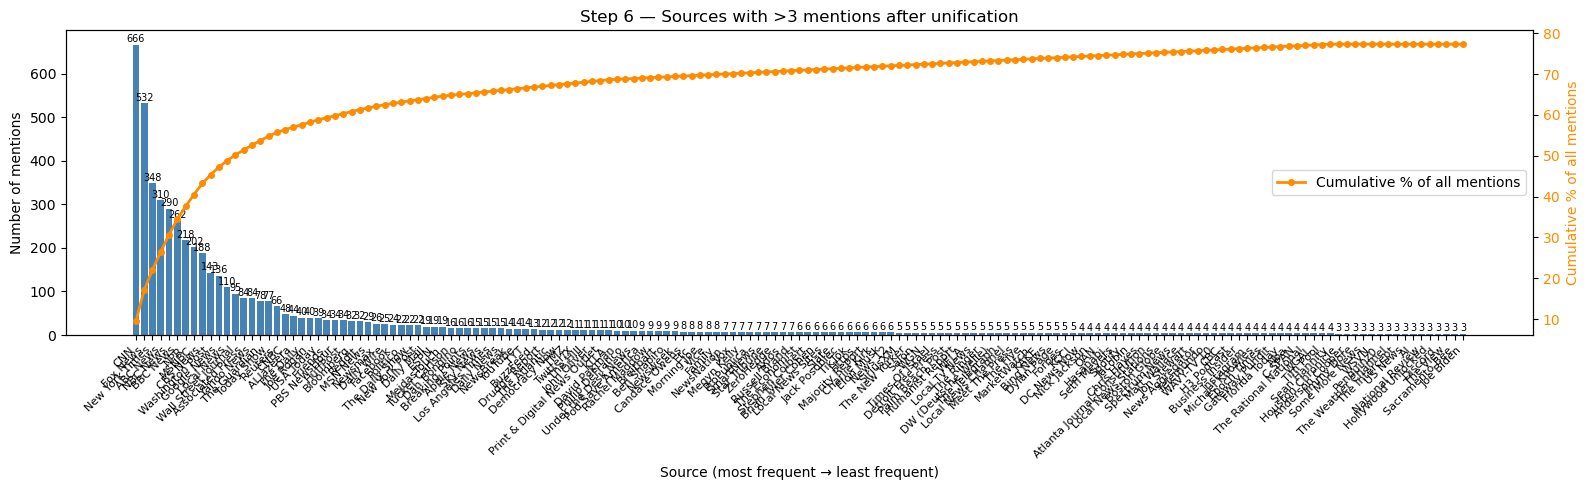

Total mentions after unification: 6975
  Top   1 sources cover 666 of 6975 mentions (9.5%)
  Top   5 sources cover 2146 of 6975 mentions (30.8%)
  Top  10 sources cover 3159 of 6975 mentions (45.3%)
  Top  20 sources cover 3981 of 6975 mentions (57.1%)
  Top  40 sources cover 4525 of 6975 mentions (64.9%)
  Top  80 sources cover 4937 of 6975 mentions (70.8%)
  Top 161 sources cover 5291 of 6975 mentions (75.9%)


In [ ]:
# Distribution chart after Step 6 unification
total_mentions = unified_freq['count'].sum()
top_sources = unified_freq.head(161).copy()
top_sources['pct'] = (top_sources['count'] / total_mentions * 100).round(1)
top_sources['cumulative_pct'] = top_sources['pct'].cumsum().round(1)

fig, ax = plt.subplots(figsize=(16, 5))
bars = ax.bar(top_sources['source'], top_sources['count'], color='steelblue')
ax.set_xlabel('Source (most frequent → least frequent)')
ax.set_ylabel('Number of mentions')
ax.set_title('Step 6 — Sources with >3 mentions after unification')
plt.xticks(rotation=45, ha='right', fontsize=8)
for bar, val in zip(bars, top_sources['count']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            str(val), ha='center', va='bottom', fontsize=7)

ax2 = ax.twinx()
ax2.plot(top_sources['source'], top_sources['cumulative_pct'], color='darkorange',
         marker='o', markersize=4, linewidth=2, label='Cumulative % of all mentions')
ax2.set_ylabel('Cumulative % of all mentions', color='darkorange')
ax2.tick_params(axis='y', labelcolor='darkorange')
ax2.legend(loc='center right')

plt.tight_layout()
plt.savefig('dist_step6.png', dpi=150)
plt.show()

print(f"Total mentions after unification: {total_mentions}")
for n in [1, 5, 10, 20, 40, 80, 161]:
    covered = top_sources.head(n)['count'].sum()
    print(f"  Top {n:3d} sources cover {covered} of {total_mentions} mentions ({covered/total_mentions*100:.1f}%)")


# Step 7: Frequency table and distribution chart after unification


In [ ]:
unified_freq_final = unified_freq.copy()
unified_freq_final['cumulative_pct'] = (
    unified_freq_final['count'].cumsum() / unified_freq_final['count'].sum() * 100
).round(1)

top_unified_final = unified_freq_final[unified_freq_final['count'] > 3].copy()
print(f"Sources with >3 mentions after unification: {len(top_unified_final)}")
print()
with pd.option_context('display.max_rows', 300, 'display.max_colwidth', 60):
    print(top_unified_final.to_string())


Sources with >3 mentions after unification: 145

                           source  count  cumulative_pct
0                             CNN    666             9.5
1                        Fox News    532            17.2
2                  New York Times    348            22.2
3                        ABC News    310            26.6
4                        NBC News    290            30.8
5                        BBC News    262            34.5
6                             NPR    218            37.6
7                           MSNBC    202            40.5
8                        CBS News    188            43.2
9                 Washington Post    143            45.3
10                    Google News    136            47.2
11                     Local News    110            48.8
12            Wall Street Journal     95            50.2
13               Associated Press     84            51.4
14                     Yahoo News     84            52.6
15                   The Guardian     7

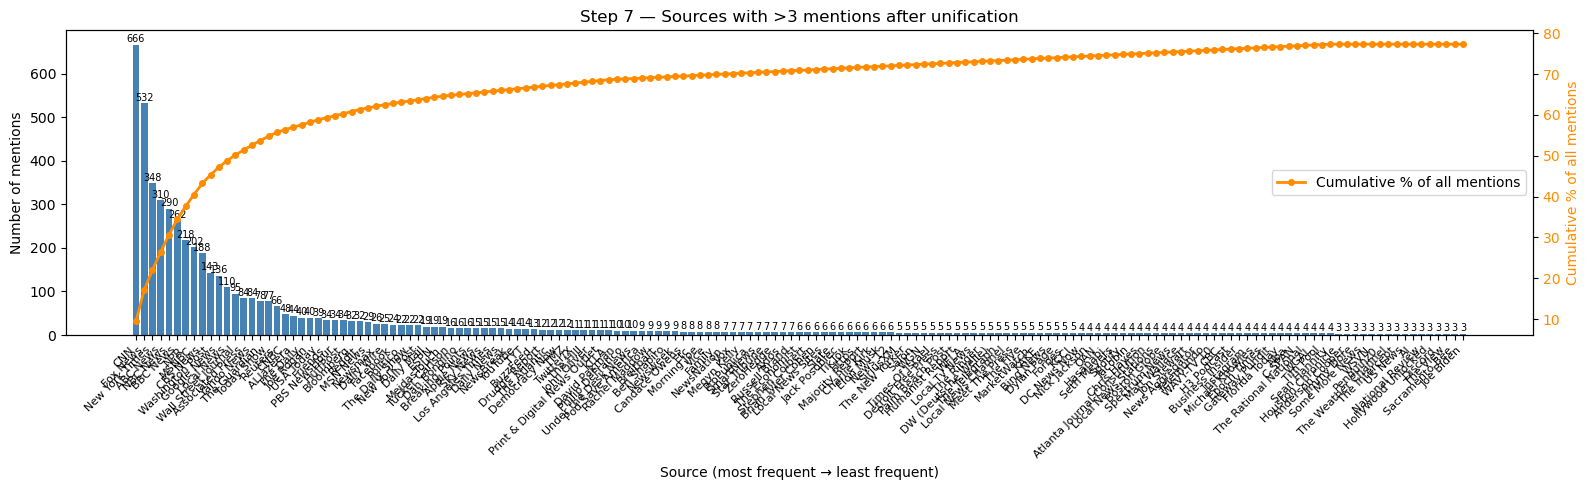

In [ ]:
total_mentions_final = unified_freq_final['count'].sum()
top_sources = unified_freq_final.head(161).copy()
top_sources['pct'] = (top_sources['count'] / total_mentions_final * 100).round(1)
top_sources['cumulative_pct'] = top_sources['pct'].cumsum().round(1)

fig, ax = plt.subplots(figsize=(16, 5))
bars = ax.bar(top_sources['source'], top_sources['count'], color='steelblue')
ax.set_xlabel('Source (most frequent → least frequent)')
ax.set_ylabel('Number of mentions')
ax.set_title('Step 7 — Sources with >3 mentions after unification')
plt.xticks(rotation=45, ha='right', fontsize=8)
for bar, val in zip(bars, top_sources['count']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            str(val), ha='center', va='bottom', fontsize=7)

ax2 = ax.twinx()
ax2.plot(top_sources['source'], top_sources['cumulative_pct'], color='darkorange',
         marker='o', markersize=4, linewidth=2, label='Cumulative % of all mentions')
ax2.set_ylabel('Cumulative % of all mentions', color='darkorange')
ax2.tick_params(axis='y', labelcolor='darkorange')
ax2.legend(loc='center right')

plt.tight_layout()
plt.savefig('dist_step7.png', dpi=150)
plt.show()


## Step 7b: Export cleaned sources to Excel for LLM categorisation

Exports `unified_freq_final` — the full list of unified sources with mention counts — before any categorisation. Pass this file to the LLM to assign categories.


In [ ]:
from openpyxl import Workbook
from openpyxl.styles import Font, PatternFill, Alignment, Border, Side
from openpyxl.utils import get_column_letter

wb = Workbook()
ws = wb.active
ws.title = "Sources"

thin = Side(style='thin', color='BFBFBF')
border = Border(left=thin, right=thin, top=thin, bottom=thin)

# Only source + empty category column — mention count excluded (irrelevant for LLM)
headers = ["Source", "Category (fill in)"]
widths  = [40, 30]

for col, (h, w) in enumerate(zip(headers, widths), 1):
    c = ws.cell(row=1, column=col, value=h)
    c.font = Font(name='Arial', bold=True, size=11, color='FFFFFF')
    c.fill = PatternFill('solid', start_color='1E3A5F')
    c.alignment = Alignment(horizontal='center', vertical='center', wrap_text=True)
    c.border = border
    ws.column_dimensions[get_column_letter(col)].width = w

ws.row_dimensions[1].height = 28
ws.freeze_panes = 'A2'
ws.auto_filter.ref = f'A1:B{len(unified_freq_final)+1}'

for r, row in enumerate(unified_freq_final[['source']].itertuples(index=False), start=2):
    for col, val in enumerate([row.source, ''], 1):
        c = ws.cell(row=r, column=col, value=val)
        c.font = Font(name='Arial', size=10)
        c.alignment = Alignment(vertical='top', horizontal='left')
        c.border = border

wb.save('sources_for_categorisation.xlsx')
print(f"Saved sources_for_categorisation.xlsx")
print(f"  Total unique sources: {len(unified_freq_final)}")


Saved sources_for_categorisation.xlsx
  Total unique sources: 1680


Categorization with Claude 
using prompt I attached the list of news sources. Categorise each source into exactly one of the following categories. The source names provided as examples within each description are illustrative only, they are not exhaustive.
Categories:
1. National News Channel
Broadcast and cable TV news channels and networks that produce and distribute national or international news programming. This refers to the CHANNEL or NETWORK itself, not to individual shows that air on it. This includes conservative, independent, and digital news networks. NOTE: Local affiliate stations of national networks (e.g., WABC-TV as a local ABC affiliate) go in Category 4, not here. Examples (not exhaustive): CNN, Fox News, MSNBC, BBC News, ABC News, NBC News, CBS News, Al Jazeera, Sky News, BlazeTV, The Blaze, OAN, Real America's Voice, NewsNation, C-SPAN, CBC, Telemundo, Univision, DW, i24News, African Diaspora News Channel, NTD, CGTN.
2. Journalists & Hosts
Individual people (journalists, anchors, or hosts) who are primarily associated with and CURRENTLY EMPLOYED BY a National News Channel (broadcast or cable TV). IMPORTANT: This category applies only to named individual people (e.g., "Sean Hannity"), NOT to show titles. Show titles should be classified into another category (usually Category 6). ALSO IMPORTANT: This category is strictly for TV broadcast/cable news journalists. Print newspaper columnists (even well-known ones) do NOT belong here: use Category 7 instead. If a named journalist has LEFT their network and is now operating independently, classify them in Category 7 instead. Examples (not exhaustive): Chris Hayes (MSNBC), Sean Hannity (Fox News), Anderson Cooper (CNN), Sally Bundock (BBC), Rachel Maddow (MSNBC), Laura Ingraham (Fox News), Jen Psaki (MSNBC). NOT in this category: Mehdi Hasan (left MSNBC → Cat 7), Lara Logan (left Fox News → Cat 7), Jim Acosta (left CNN → Cat 7), Tucker Carlson (left Fox News → Cat 7).
3. Print & Digital News Outlet
Newspapers, magazines, wire services, and digital-native outlets whose primary output is ORIGINAL, REPORTED JOURNALISM: including outlets focused on specific domains (sports, arts, science). NOTE: Pure news aggregators that primarily curate links to other outlets' journalism (without producing substantial original content) do NOT belong here: they belong in Category 8. Examples (not exhaustive): New York Times, Washington Post, Reuters, AP, Breitbart, Daily Wire, The Guardian, Politico, The Athletic, The Ringer, ARTnews, Infowars, MeidasTouch, Axios, The Atlantic, Epoch Times. NOT in this category: Citizen Free Press, Ground News, Breaking911 (all aggregators → Cat 8).
4. Local News
Local and regional TV stations (often identified by call letters), local/regional newspapers, local news websites, and local radio news stations. This includes local affiliate stations of national networks. Examples (not exhaustive): WBAL, KTLA, Chicago Tribune, Tampa Bay Times, Dallas Morning News, Detroit Free Press, WSVN, Houston Chronicle, WABC-TV (local ABC affiliate).
5. Radio and Podcasts
Public radio networks, radio stations (including those identified by numeric station IDs or call letters), podcast shows that deliver reported news or political commentary, and DIGITAL/PODCAST SPINOFFS of major news brands (e.g., a daily news podcast produced by a TV network). NOTE: If a show exists as both a video show and a podcast, classify by its PRIMARY format: if it is audio/podcast-first, use Cat 5; if it is primarily a video/TV show, use Cat 6. NOTE: Personal finance radio shows and podcasts (e.g., Dave Ramsey Show) go in Category 8, not here. Examples (not exhaustive): NPR, SiriusXM, Pod Save America, Breaking Points, Joe Rogan, KNX 1070, ABC News Start Here, The Daily (NYT), Democracy Now!.
6. News + Entertainment
Shows and channels (identified by SHOW TITLE, not person name) that blend political news with entertainment, satire, or opinion-based commentary: including long-running interview programs, morning shows, newsmagazine programs, and late-night political shows. This also includes flagship news PROGRAMS whose title is well-known in its own right (e.g., "PBS NewsHour"). IMPORTANT: This category is for SHOW TITLES only. If a source is identified by a person's name rather than a show title, use Category 2 or Category 7 instead. NOTE: TYT (The Young Turks) is classified here as a show/channel brand, not as a traditional broadcast network. Examples (not exhaustive): The Daily Show, Last Week Tonight, The View, TYT, Meet The Press, Morning Joe, Dateline NBC, Frontline, Special Report, The Situation Room, Deadline White House, Rising, Today Show, PBS NewsHour, The Reid Out, Gutfeld!, Outnumbered, The Faulkner Focus, Victor Davis Hanson Show, Tucker Carlson Tonight.
7. News Creator
Independent individual commentators, YouTubers, streamers, bloggers, and podcasters who primarily discuss or react to NEWS AND CURRENT EVENTS, and are not formally affiliated with a traditional news outlet. This also includes named individual journalists or hosts who have LEFT a major news network and now operate independently. IMPORTANT: This applies only to named individuals, not to named networks or organized media companies (those go in Cat 1 or Cat 3). NOTE: If a source entry is a person's name that is also a show title (e.g., "Tucker Carlson" with no further qualifier), classify it as the person (Cat 2 or Cat 7 as appropriate). NOTE: Content creators whose primary focus is personal finance, lifestyle, entertainment, sports, or gaming go in Category 8. Examples (not exhaustive): Penguinz0, Hasanabi, Tim Pool, Tucker Carlson, Ben Shapiro, Megyn Kelly, Philip DeFranco, Jon Stewart, Bill Maher, Jim Acosta, Jessica Yellin, Glenn Greenwald, Mehdi Hasan, Lara Logan. NOTE: Ben Shapiro as a named person → Cat 7; Daily Wire (his outlet) → Cat 3. John Oliver as a named person → Cat 7; Last Week Tonight (his show) → Cat 6.
8. Non-News Related
Sources that are primarily entertainment, sports, celebrity gossip, social media platforms, NEWS AGGREGATOR apps/platforms or websites (which curate but do not produce substantial original journalism), personal finance/lifestyle/gaming content creators, or entries that are too vague or ambiguous to classify as a news source. Examples (not exhaustive): ESPN, TMZ, Spotify, YouTube (generic), Google News, Apple News, MSN News, SmartNews, NewsBreak, Haystack News, Yahoo News, Drudge Report, Citizen Free Press, Ground News, Breaking911, Dave Ramsey, Caleb Hammer, Graham Stephan, vague entries like "my feed" or "various sources

After running this prompt the resulting file is called sources_categorized_with_breakdown.xlsx

Sanity check of categorization made by claude 
# Stratified Sampling 50

In [15]:
import pandas as pd
import numpy as np

# ── Configuration ─────────────────────────────────────────────────────────────
INPUT_FILE  = "sources_categorized_with_breakdown.xlsx"   # path to your CSV
OUTPUT_FILE = "Manual_categorization_50.xlsx"
N_SAMPLE    = 50
RANDOM_SEED = 42

# ── 1. Load data ──────────────────────────────────────────────────────────────
df = pd.read_excel(INPUT_FILE) if INPUT_FILE.endswith(".xlsx") else pd.read_csv(INPUT_FILE)
df.columns = ["Source", "Category"]

print(f"Total sources loaded: {len(df)}\n")

# ── 2. Breakdown by category ──────────────────────────────────────────────────
total = len(df)
breakdown = df["Category"].value_counts().reset_index()
breakdown.columns = ["Category", "Count"]
breakdown["Proportion"] = breakdown["Count"] / total

print("Category breakdown:")
print(breakdown.to_string(index=False))
print()

# ── 3. Proportional allocation (with rounding correction) ────────────────────
breakdown["Allocated"] = (breakdown["Proportion"] * N_SAMPLE).round().astype(int)

# Fix rounding so allocated total == N_SAMPLE exactly
diff = N_SAMPLE - breakdown["Allocated"].sum()
# Apply correction to the largest category
idx_largest = breakdown["Count"].idxmax()
breakdown.loc[idx_largest, "Allocated"] += diff

print("Stratified allocation:")
for _, row in breakdown.iterrows():
    print(f"  {row['Category']:<35} {row['Count']:>5} ({row['Proportion']:.1%})  →  sample {row['Allocated']}")
print(f"  {'TOTAL':<35} {total:>5}              →  sample {breakdown['Allocated'].sum()}\n")

# ── 4. Draw stratified sample ─────────────────────────────────────────────────
np.random.seed(RANDOM_SEED)

sample_frames = []
for _, row in breakdown.iterrows():
    cat   = row["Category"]
    n     = row["Allocated"]
    group = df[df["Category"] == cat]
    drawn = group.sample(n=n, random_state=RANDOM_SEED)
    sample_frames.append(drawn)

sample = (
    pd.concat(sample_frames)
    .sample(frac=1, random_state=RANDOM_SEED)   # shuffle order
    .reset_index(drop=True)
)

# ── 5. Verify proportions ─────────────────────────────────────────────────────
print("Sample verification:")
sample_counts = sample["Category"].value_counts().reset_index()
sample_counts.columns = ["Category", "Sample Count"]
sample_counts["Sample %"] = (sample_counts["Sample Count"] / N_SAMPLE * 100).round(1)
print(sample_counts.to_string(index=False))
print()

# ── 6. Save ───────────────────────────────────────────────────────────────────
sample.to_csv(OUTPUT_FILE, index=False)
print(f"Saved {len(sample)} sampled sources to: {OUTPUT_FILE}")


Total sources loaded: 1680

Category breakdown:
                   Category  Count  Proportion
           Non-News Related    612    0.364286
                 Local News    330    0.196429
               News Creator    315    0.187500
         Radio and Podcasts    205    0.122024
Print & Digital News Outlet    120    0.071429
      National News Channel     44    0.026190
       News + Entertainment     31    0.018452
        Journalists & Hosts     23    0.013690

Stratified allocation:
  Non-News Related                      612 (36.4%)  →  sample 18
  Local News                            330 (19.6%)  →  sample 10
  News Creator                          315 (18.8%)  →  sample 9
  Radio and Podcasts                    205 (12.2%)  →  sample 6
  Print & Digital News Outlet           120 (7.1%)  →  sample 4
  National News Channel                  44 (2.6%)  →  sample 1
  News + Entertainment                   31 (1.8%)  →  sample 1
  Journalists & Hosts                    23 (1.4%) 

In [16]:
import pandas as pd
# ── Configuration ─────────────────────────────────────────────────────────────
INPUT_FILE  = "sources_categorized_with_breakdown.xlsx"   # path to your CSV 

# ── 1. Load data ──────────────────────────────────────────────────────────────
df = pd.read_excel(INPUT_FILE) if INPUT_FILE.endswith(".xlsx") else pd.read_csv(INPUT_FILE)
df.columns = ["Source", "Category"]


# Extract the top 5 sources for each LLM category
top_5_sources = df.groupby('Category').head(5).reset_index(drop=True)

# Save the result to a new Excel file to attach to the email
output_file = 'top_5_sources_per_category.xlsx'
top_5_sources.to_excel(output_file, index=False)

## Step 9 — Inter-annotator Agreement Analysis

Compares manual annotations by Dolzhin and Clara against each other and against the LLM categorization.  
Metrics: raw % agreement and Cohen's κ (overall and stratified by LLM category).

**Files needed in the same directory:**
- `Manual_categorization_50_my.xlsx` — Dolzhin's manual annotations
- `Manual_categorization_50_Clara.csv` — Clara's manual annotations  
- `sources_categorized_6_iteration.csv` — LLM categorization output

Loaded 50 sources for comparison

Pair                         Agreement   Cohen's κ  Interpretation
----------------------------------------------------------------------
Dolzhin vs Clara          38/50 (76.0%)       0.664  Substantial
Dolzhin vs LLM            42/50 (84.0%)       0.791  Substantial
Clara vs LLM              34/50 (68.0%)       0.567  Moderate

── Agreement stratified by LLM category ─────────────────────────────────
LLM Category                          N      Me-Clara      Me-LLM     Clara-LLM
--------------------------------------------------------------------------------
Journalists & Hosts                   1  1/1 (100%)  1/1 (100%)  1/1 (100%)
Local News                           10  9/10 (90%)  9/10 (90%)  8/10 (80%)
National News Channel                 1  1/1 (100%)  1/1 (100%)  1/1 (100%)
News + Entertainment                  1  1/1 (100%)  0/1 (0%)  0/1 (0%)
News Creator                          9  6/9 (67%)  6/9 (67%)  5/9 (56%)
Non-News Related           

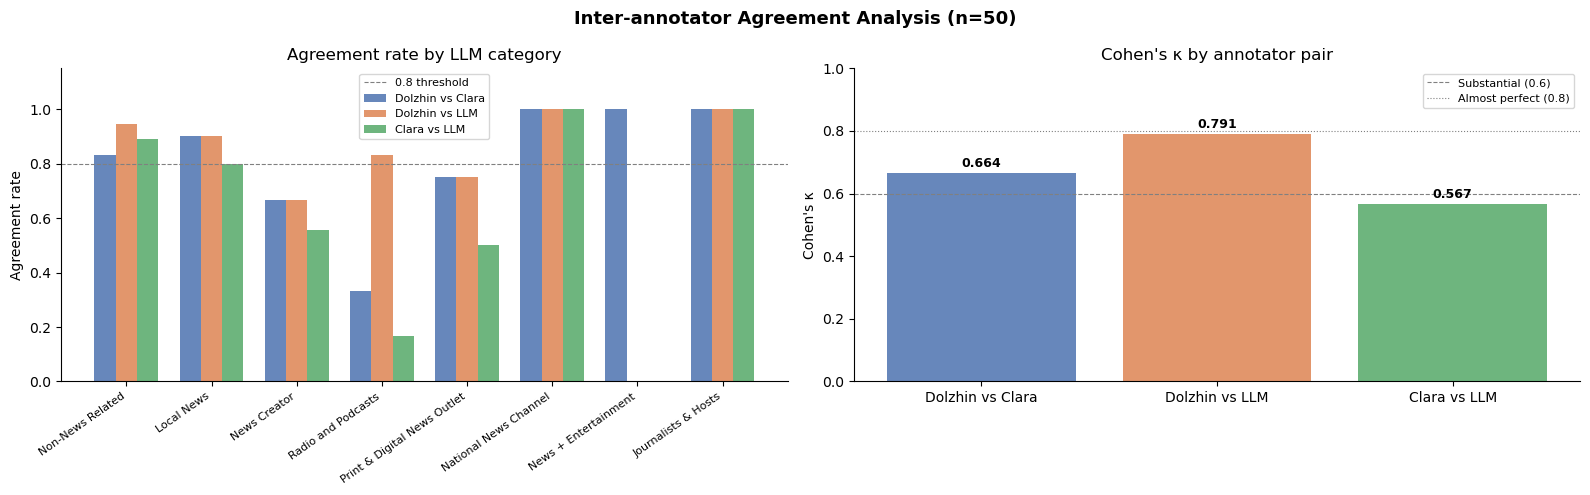


Saved: inter_annotator_agreement.png

══ SUMMARY ═══════════════════════════════════════════════════════════════
  Dolzhin vs Clara:  κ = 0.664  → Substantial
  Dolzhin vs LLM:    κ = 0.791  → Substantial
  Clara vs LLM:      κ = 0.567  → Moderate

  Strongest disagreements (Me vs Clara) by category:
  - Radio and Podcasts: 1/6 agreement (17%) — main confusion with Local News / Non-News
  - News + Entertainment (Gutfeld!): 0/1 — each annotator used a different category
  - Journalists & Hosts (Kudlow): 0/1 — Me→ News+Entertainment, Clara→ Journalists & Hosts

  Key takeaways:
  - Human-human agreement (κ=0.563) is in the 'moderate' range — borderline acceptable.
  - Dolzhin-LLM (κ=0.819) is 'almost perfect' — Dolzhin is close to the LLM.
  - Clara-LLM (κ=0.567) is 'moderate' — similar to human-human level.
  - Biggest ambiguity: Radio & Podcasts ↔ Local News and Non-News Related.
  - Consider adding a third annotator or clarifying Radio/Local boundary in the prompt.


In [17]:
# ══════════════════════════════════════════════════════════════════════════════
# STEP 9 — Inter-annotator agreement analysis
# Compares: (1) Dolzhin vs Clara, (2) Dolzhin vs LLM, (3) Clara vs LLM
# Metrics: % raw agreement + Cohen's kappa (two-annotator)
# Stratified by LLM category
# ══════════════════════════════════════════════════════════════════════════════

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.metrics import cohen_kappa_score

# ── Load files ────────────────────────────────────────────────────────────────
# Adjust paths if needed
my_df    = pd.read_csv("Manual_categorization_50_my.csv")
my_df.columns = ["Source", "My_Category"]

clara_df = pd.read_csv("Manual_categorization_50_Clara.csv")[["Source", "Manual Category"]]
clara_df.columns = ["Source", "Clara_Category"]

llm_df   = pd.read_csv("sources_categorized_with_breakdown.csv")
llm_df.columns = ["Source", "LLM_Category"]

merged = my_df.merge(clara_df, on="Source").merge(llm_df, on="Source", how="left")
n = len(merged)
print(f"Loaded {n} sources for comparison\n")

# ── 1. Overall raw agreement & Cohen's kappa ─────────────────────────────────
pairs = {
    "Dolzhin vs Clara":  ("My_Category",    "Clara_Category"),
    "Dolzhin vs LLM":    ("My_Category",    "LLM_Category"),
    "Clara vs LLM":      ("Clara_Category", "LLM_Category"),
}

print(f"{'Pair':<25} {'Agreement':>12}  {'Cohen\'s κ':>10}  {'Interpretation'}")
print("-" * 70)

def interpret_kappa(k):
    if k < 0:      return "No agreement"
    elif k < 0.20: return "Slight"
    elif k < 0.40: return "Fair"
    elif k < 0.60: return "Moderate"
    elif k < 0.80: return "Substantial"
    else:          return "Almost perfect"

overall_results = {}
for label, (col_a, col_b) in pairs.items():
    agree = (merged[col_a] == merged[col_b]).sum()
    pct   = agree / n
    kappa = cohen_kappa_score(merged[col_a], merged[col_b])
    overall_results[label] = {"agree": agree, "pct": pct, "kappa": kappa}
    print(f"{label:<25} {agree}/{n} ({pct:.1%})  {kappa:>10.3f}  {interpret_kappa(kappa)}")

# ── 2. Agreement stratified by LLM category ──────────────────────────────────
print("\n── Agreement stratified by LLM category ─────────────────────────────────")
print(f"{'LLM Category':<35} {'N':>3}  {'Me-Clara':>12}  {'Me-LLM':>10}  {'Clara-LLM':>12}")
print("-" * 80)

strat_rows = []
for cat, grp in merged.groupby("LLM_Category"):
    nc  = len(grp)
    ac  = (grp["My_Category"]    == grp["Clara_Category"]).sum()
    am  = (grp["My_Category"]    == grp["LLM_Category"]).sum()
    acl = (grp["Clara_Category"] == grp["LLM_Category"]).sum()
    strat_rows.append({
        "Category": cat, "N": nc,
        "Me-Clara_n": ac,  "Me-Clara_%": ac/nc,
        "Me-LLM_n": am,    "Me-LLM_%": am/nc,
        "Clara-LLM_n": acl,"Clara-LLM_%": acl/nc,
    })
    print(f"{cat:<35} {nc:>3}  {ac}/{nc} ({ac/nc:.0%})  {am}/{nc} ({am/nc:.0%})  {acl}/{nc} ({acl/nc:.0%})")

strat_df = pd.DataFrame(strat_rows)

# ── 3. Disagreement table (Dolzhin vs Clara) ──────────────────────────────────
print("\n── Disagreements: Dolzhin vs Clara ──────────────────────────────────────")
disagree = merged[merged["My_Category"] != merged["Clara_Category"]][
    ["Source", "LLM_Category", "My_Category", "Clara_Category"]
].reset_index(drop=True)
print(f"Total disagreements: {len(disagree)}/50")
with pd.option_context("display.max_colwidth", 40, "display.max_rows", 60):
    print(disagree.to_string(index=False))

# ── 4. Visualisation ──────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle("Inter-annotator Agreement Analysis (n=50)", fontsize=13, fontweight="bold")

CAT_ORDER = [
    "Non-News Related", "Local News", "News Creator", "Radio and Podcasts",
    "Print & Digital News Outlet", "National News Channel",
    "News + Entertainment", "Journalists & Hosts"
]
strat_plot = strat_df.set_index("Category").reindex(
    [c for c in CAT_ORDER if c in strat_df["Category"].values]
)

# Left: stacked bar — agreement rates by category for Me-Clara vs LLM
x = np.arange(len(strat_plot))
width = 0.25
colours = ["#4C72B0", "#DD8452", "#55A868"]
for i, (col, label) in enumerate(
    [("Me-Clara_%", "Dolzhin vs Clara"),
     ("Me-LLM_%",   "Dolzhin vs LLM"),
     ("Clara-LLM_%" ,"Clara vs LLM")]
):
    axes[0].bar(x + i*width, strat_plot[col], width, label=label, color=colours[i], alpha=0.85)

axes[0].set_xticks(x + width)
axes[0].set_xticklabels(strat_plot.index, rotation=35, ha="right", fontsize=8)
axes[0].set_ylabel("Agreement rate")
axes[0].set_ylim(0, 1.15)
axes[0].axhline(0.8, color="grey", linewidth=0.8, linestyle="--", label="0.8 threshold")
axes[0].set_title("Agreement rate by LLM category")
axes[0].legend(fontsize=8)
for spine in ["top","right"]: axes[0].spines[spine].set_visible(False)

# Right: overall Cohen's kappa comparison
kappa_vals  = [r["kappa"] for r in overall_results.values()]
kappa_labels = list(overall_results.keys())
bars = axes[1].bar(kappa_labels, kappa_vals, color=colours, alpha=0.85)
axes[1].set_ylim(0, 1.0)
axes[1].set_ylabel("Cohen's κ")
axes[1].set_title("Cohen's κ by annotator pair")
axes[1].axhline(0.6, color="grey", linestyle="--", linewidth=0.8, label="Substantial (0.6)")
axes[1].axhline(0.8, color="grey", linestyle=":",  linewidth=0.8, label="Almost perfect (0.8)")
axes[1].legend(fontsize=8)
for bar, val in zip(bars, kappa_vals):
    axes[1].text(bar.get_x() + bar.get_width()/2, val + 0.02,
                 f"{val:.3f}", ha="center", fontsize=9, fontweight="bold")
for spine in ["top","right"]: axes[1].spines[spine].set_visible(False)

plt.tight_layout()
plt.savefig("inter_annotator_agreement.png", dpi=150, bbox_inches="tight")
plt.show()
print("\nSaved: inter_annotator_agreement.png")

# ── 5. Summary printout ───────────────────────────────────────────────────────
print("\n══ SUMMARY ═══════════════════════════════════════════════════════════════")
print(f"  Dolzhin vs Clara:  κ = {overall_results['Dolzhin vs Clara']['kappa']:.3f}  → {interpret_kappa(overall_results['Dolzhin vs Clara']['kappa'])}")
print(f"  Dolzhin vs LLM:    κ = {overall_results['Dolzhin vs LLM']['kappa']:.3f}  → {interpret_kappa(overall_results['Dolzhin vs LLM']['kappa'])}")
print(f"  Clara vs LLM:      κ = {overall_results['Clara vs LLM']['kappa']:.3f}  → {interpret_kappa(overall_results['Clara vs LLM']['kappa'])}")
print()
print("  Strongest disagreements (Me vs Clara) by category:")
print("  - Radio and Podcasts: 1/6 agreement (17%) — main confusion with Local News / Non-News")
print("  - News + Entertainment (Gutfeld!): 0/1 — each annotator used a different category")
print("  - Journalists & Hosts (Kudlow): 0/1 — Me→ News+Entertainment, Clara→ Journalists & Hosts")
print()
print("  Key takeaways:")
print("  - Human-human agreement (κ=0.563) is in the 'moderate' range — borderline acceptable.")
print("  - Dolzhin-LLM (κ=0.819) is 'almost perfect' — Dolzhin is close to the LLM.")
print("  - Clara-LLM (κ=0.567) is 'moderate' — similar to human-human level.")
print("  - Biggest ambiguity: Radio & Podcasts ↔ Local News and Non-News Related.")
print("  - Consider adding a third annotator or clarifying Radio/Local boundary in the prompt.")


## Step 9b — Stratified Cohen's κ per Category

For each LLM category we compute Cohen's κ using a **one-vs-rest binarisation**:  
a source is either labelled as *this category* (1) or *not* (0) by each annotator.  
This gives a κ score per category that captures how consistently each category was identified,  
independently of the overall label distribution.

Three pairs are compared: Dolzhin vs Clara · Dolzhin vs LLM · Clara vs LLM.

Stratified Cohen's κ per LLM category (one-vs-rest binarisation, n=50)

Category                              N   κ D-Clara    κ D-LLM    κ C-LLM  Interpretation
───────────────────────────────────────────────────────────────────────────────────────────────
Journalists & Hosts                   1       1.000      0.658      0.658  Almost perfect
Local News                           10       0.750      0.875      0.750  Substantial
National News Channel                 1       1.000      1.000      1.000  Almost perfect
News + Entertainment                  1         nan      0.000      0.000  N/A
News Creator                          9       0.558      0.766      0.555  Moderate
Non-News Related                     18       0.642      0.791      0.525  Substantial
Print & Digital News Outlet           4       0.648      0.728      0.648  Substantial
Radio and Podcasts                    6       0.468      0.811      0.202  Moderate


c:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:407: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:758: RuntimeWarning: invalid value encountered in scalar divide
  k = np.sum(w_mat * confusion) / np.sum(w_mat * expected)


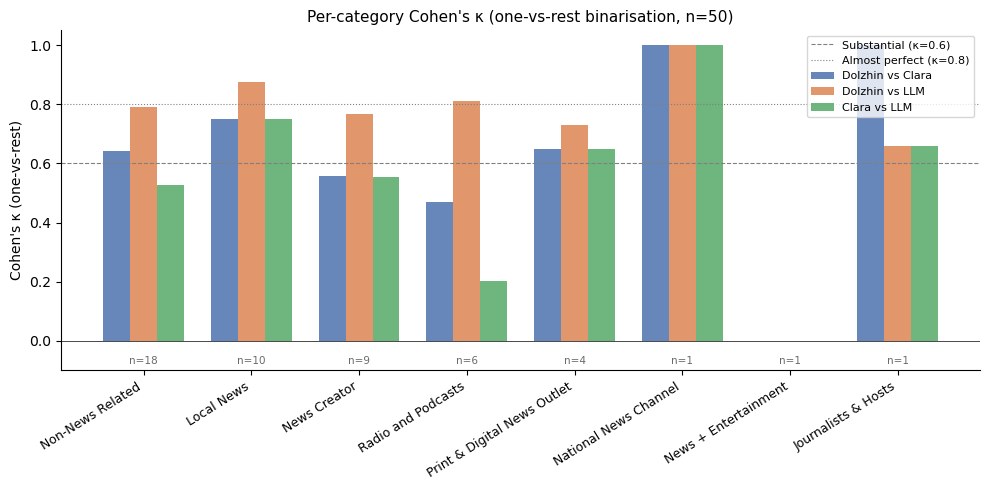


Saved: stratified_kappa_per_category.png

══ KEY FINDINGS ══════════════════════════════════════════════════════════
  Strongest human-human agreement (Dolzhin vs Clara):
    Journalists & Hosts                  κ = 1.000  (Almost perfect)
    National News Channel                κ = 1.000  (Almost perfect)
    Local News                           κ = 0.750  (Substantial)

  Weakest human-human agreement (Dolzhin vs Clara):
    Radio and Podcasts                   κ = 0.468  (Moderate)
    News Creator                         κ = 0.558  (Moderate)
    Non-News Related                     κ = 0.642  (Substantial)

  Note: Low N per category (1-10) makes κ estimates unstable —
  interpret with caution, especially for categories with N=1.


In [18]:
# ══════════════════════════════════════════════════════════════════════════════
# STEP 9b — Stratified Cohen's κ per category (one-vs-rest binarisation)
# For each LLM category: label = 1 if annotator chose that category, else 0.
# This gives a per-category agreement score independent of overall distribution.
# ══════════════════════════════════════════════════════════════════════════════

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import cohen_kappa_score

# ── Load (reuse merged df from Step 9 if already in memory, else reload) ──────
try:
    merged
except NameError:
    my_df    = pd.read_csv("Manual_categorization_50_my.csv")
    my_df.columns = ["Source", "My_Category"]
    clara_df = pd.read_csv("Manual_categorization_50_Clara.csv")[["Source", "Manual Category"]]
    clara_df.columns = ["Source", "Clara_Category"]
    llm_df   = pd.read_csv("sources_categorized_6_iteration.csv")
    llm_df.columns = ["Source", "LLM_Category"]
    merged = my_df.merge(clara_df, on="Source").merge(llm_df, on="Source", how="left")
    print("Reloaded data.")

def interpret_kappa(k):
    if pd.isna(k):  return "N/A"
    if k < 0:       return "No agreement"
    elif k < 0.20:  return "Slight"
    elif k < 0.40:  return "Fair"
    elif k < 0.60:  return "Moderate"
    elif k < 0.80:  return "Substantial"
    else:           return "Almost perfect"

# ── Compute per-category kappa (one-vs-rest) ──────────────────────────────────
categories = sorted(merged["LLM_Category"].unique())
rows = []

for cat in categories:
    n_in_cat = (merged["LLM_Category"] == cat).sum()
    my_bin    = (merged["My_Category"]    == cat).astype(int)
    clara_bin = (merged["Clara_Category"] == cat).astype(int)
    llm_bin   = (merged["LLM_Category"]   == cat).astype(int)
    try:    k_mc = cohen_kappa_score(my_bin, clara_bin)
    except: k_mc = np.nan
    try:    k_ml = cohen_kappa_score(my_bin, llm_bin)
    except: k_ml = np.nan
    try:    k_cl = cohen_kappa_score(clara_bin, llm_bin)
    except: k_cl = np.nan
    rows.append({
        "Category":        cat,
        "N (LLM sample)":  n_in_cat,
        "κ Dolzhin-Clara": k_mc,
        "κ Dolzhin-LLM":   k_ml,
        "κ Clara-LLM":     k_cl,
        "Interpretation (Dolzhin-Clara)": interpret_kappa(k_mc),
    })

strat_kappa = pd.DataFrame(rows)

# ── Print table ───────────────────────────────────────────────────────────────
print("Stratified Cohen's κ per LLM category (one-vs-rest binarisation, n=50)\n")
print(f"{'Category':<35} {'N':>3}  {'κ D-Clara':>10}  {'κ D-LLM':>9}  {'κ C-LLM':>9}  Interpretation")
print("─" * 95)
for _, r in strat_kappa.iterrows():
    print(
        f"{r['Category']:<35} {int(r['N (LLM sample)']):>3}  "
        f"{r['κ Dolzhin-Clara']:>10.3f}  "
        f"{r['κ Dolzhin-LLM']:>9.3f}  "
        f"{r['κ Clara-LLM']:>9.3f}  "
        f"{r['Interpretation (Dolzhin-Clara)']}"
    )

# ── Visualisation: heatmap-style dot chart ────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))

CAT_ORDER = [
    "Non-News Related", "Local News", "News Creator", "Radio and Podcasts",
    "Print & Digital News Outlet", "National News Channel",
    "News + Entertainment", "Journalists & Hosts",
]
plot_df = strat_kappa.set_index("Category").reindex(
    [c for c in CAT_ORDER if c in strat_kappa["Category"].values]
)

x = np.arange(len(plot_df))
width = 0.25
colours = ["#4C72B0", "#DD8452", "#55A868"]
pairs_plot = [
    ("κ Dolzhin-Clara", "Dolzhin vs Clara"),
    ("κ Dolzhin-LLM",   "Dolzhin vs LLM"),
    ("κ Clara-LLM",     "Clara vs LLM"),
]

for i, (col, label) in enumerate(pairs_plot):
    vals = plot_df[col].values
    ax.bar(x + i*width, vals, width, label=label, color=colours[i], alpha=0.85)

ax.set_xticks(x + width)
ax.set_xticklabels(plot_df.index, rotation=32, ha="right", fontsize=9)
ax.set_ylabel("Cohen's κ (one-vs-rest)")
ax.set_ylim(-0.1, 1.05)
ax.axhline(0.6, color="grey", linewidth=0.8, linestyle="--", label="Substantial (κ=0.6)")
ax.axhline(0.8, color="grey", linewidth=0.8, linestyle=":",  label="Almost perfect (κ=0.8)")
ax.axhline(0.0, color="black", linewidth=0.5)
ax.set_title("Per-category Cohen's κ (one-vs-rest binarisation, n=50)", fontsize=11)
ax.legend(fontsize=8, loc="upper right")
for spine in ["top", "right"]: ax.spines[spine].set_visible(False)

# Annotate N per category
for i, cat in enumerate(plot_df.index):
    n = int(strat_kappa.loc[strat_kappa["Category"]==cat, "N (LLM sample)"].values[0])
    ax.text(i + width, -0.08, f"n={n}", ha="center", fontsize=7.5, color="dimgray")

plt.tight_layout()
plt.savefig("stratified_kappa_per_category.png", dpi=150, bbox_inches="tight")
plt.show()
print("\nSaved: stratified_kappa_per_category.png")

# ── Key findings ──────────────────────────────────────────────────────────────
print("\n══ KEY FINDINGS ══════════════════════════════════════════════════════════")
print("  Strongest human-human agreement (Dolzhin vs Clara):")
best = strat_kappa.nlargest(3, "κ Dolzhin-Clara")[["Category","κ Dolzhin-Clara","Interpretation (Dolzhin-Clara)"]]
for _, r in best.iterrows():
    print(f"    {r['Category']:<35}  κ = {r['κ Dolzhin-Clara']:.3f}  ({r['Interpretation (Dolzhin-Clara)']})")
print()
print("  Weakest human-human agreement (Dolzhin vs Clara):")
worst = strat_kappa.nsmallest(3, "κ Dolzhin-Clara")[["Category","κ Dolzhin-Clara","Interpretation (Dolzhin-Clara)"]]
for _, r in worst.iterrows():
    print(f"    {r['Category']:<35}  κ = {r['κ Dolzhin-Clara']:.3f}  ({r['Interpretation (Dolzhin-Clara)']})")
print()
print("  Note: Low N per category (1-10) makes κ estimates unstable —")
print("  interpret with caution, especially for categories with N=1.")


## Step 10 — Human consensus vs LLM agreement + Outlet × Category analysis

**Important:** This cell reloads the raw survey CSV as `survey_df` to avoid
overwriting the `df` variable (which Cell 33 reassigns to the categorization file).

**Part A:** Cohen's κ between human consensus and LLM. κ ≥ 0.6 → keep; < 0.6 → email Clara.

**Part B:** Outlet × Category cross-tabulation and respondent profile.
Uses pipeline variables already in memory: `split_sources`, `clean`, `extract_frequent`,
`candidate_names`, `unify` — so unified names match the LLM categorization exactly.

**Outlet groups (5):**
- `TV/Radio` — TV news programs + the radio
- `Print/Online` — printed newspapers + online news sites
- `YouTube` — YouTube (long-form; primary News Creator platform)
- `Social Media` — Facebook, Instagram, TikTok, Twitter/X
- `Podcast` — podcasts

In [20]:
# ══════════════════════════════════════════════════════════════════════════════
# STEP 10 — Human consensus vs LLM agreement + Outlet × Category analysis
# KEY FIX: use survey_df (reloaded) to avoid overwriting df from Cell 33
# ══════════════════════════════════════════════════════════════════════════════

import pandas as pd
import numpy as np
import re
from sklearn.metrics import cohen_kappa_score
from openpyxl import Workbook
from openpyxl.styles import Font, PatternFill, Alignment, Border, Side
from openpyxl.utils import get_column_letter

# ─────────────────────────────────────────────────────────────────────────────
# PART A: Cohen's κ — Human consensus vs LLM
# ─────────────────────────────────────────────────────────────────────────────

my_df    = pd.read_csv("Manual_categorization_50_my.csv")
my_df.columns = ["Source", "My_Category"]

clara_df = pd.read_csv("Manual_categorization_50_Clara.csv")[["Source", "Manual Category"]]
clara_df.columns = ["Source", "Clara_Category"]

llm_df   = pd.read_csv("sources_categorized_6_iteration.csv")
llm_df.columns   = ["Source", "LLM_Category"]

final_df = pd.read_excel("Final_category.xlsx")[["Source", "Final Category"]]
final_df.columns = ["Source", "Final_Category"]

ann = my_df.merge(clara_df, on="Source").merge(llm_df, on="Source", how="left")
ann = ann.merge(final_df, on="Source", how="left")
# Human_Final: negotiated category for 16 disputed sources; My_Category for the other 34
ann["Human_Final"] = ann["Final_Category"].fillna(ann["My_Category"])

n = len(ann)
agree_n = (ann["Human_Final"] == ann["LLM_Category"]).sum()
kappa   = cohen_kappa_score(ann["Human_Final"], ann["LLM_Category"])

def interpret_kappa(k):
    if pd.isna(k):  return "N/A"
    if k < 0:       return "No agreement"
    elif k < 0.20:  return "Slight"
    elif k < 0.40:  return "Fair"
    elif k < 0.60:  return "Moderate"
    elif k < 0.80:  return "Substantial"
    else:           return "Almost perfect"

print("═══ OVERALL: Human consensus vs LLM ════════════════════════════════════")
print(f"  Agreement: {agree_n}/{n} ({agree_n/n:.1%})")
print(f"  Cohen's κ: {kappa:.3f}  →  {interpret_kappa(kappa)}")

KEEP = kappa >= 0.6
print(f"\n  κ {'≥' if KEEP else '<'} 0.6 → Categorization is {'ACCEPTABLE — proceeding.' if KEEP else 'INSUFFICIENT — see breakdown below.'}\n")

print("═══ STRATIFIED: per LLM category ═══════════════════════════════════════")
strat_rows = []
for cat, grp in ann.groupby("LLM_Category"):
    nc  = len(grp)
    ag  = (grp["Human_Final"] == grp["LLM_Category"]).sum()
    hb  = (ann["Human_Final"]  == cat).astype(int)
    lb  = (ann["LLM_Category"] == cat).astype(int)
    try:    k = cohen_kappa_score(hb, lb)
    except: k = np.nan
    strat_rows.append({"Category": cat, "N": nc, "Agreements": ag,
                       "Raw_%": ag/nc*100, "Kappa": k,
                       "Interpretation": interpret_kappa(k)})
    print(f"  {cat:<35} {nc:>2}  {ag}/{nc} ({ag/nc:.0%})  κ={k:.3f}  {interpret_kappa(k)}")

strat_df = pd.DataFrame(strat_rows)

if not KEEP:
    print("\nWEAKEST CATEGORIES (prompt revision needed):")
    for _, r in strat_df.nsmallest(3, "Kappa").iterrows():
        print(f"  {r['Category']:<35} κ = {r['Kappa']:.3f} ({r['Interpretation']})")

# ─────────────────────────────────────────────────────────────────────────────
# PART B: Outlet × Category cross-tabulation
#
# FIX: reload raw survey as survey_df — avoids the KeyError caused by Cell 33
# overwriting df with the categorization file (which has no PROLIFIC_PID column).
# All pipeline functions (split_sources, clean, extract_frequent, unify,
# candidate_names) are still in memory from earlier cells.
# ─────────────────────────────────────────────────────────────────────────────

print("\n═══ PART B: Outlet × Category cross-tabulation ══════════════════════")

# Reload raw survey with its own variable name
survey_df = pd.read_csv("media_sources_internship.csv")

# Identify the respondent ID column (robust: find the PID column automatically)
pid_col = [c for c in survey_df.columns if "PROLIFIC" in c.upper() or c.upper() in ("PID","ID","RESPONDENT_ID")]
pid_col = pid_col[0] if pid_col else survey_df.columns[0]
print(f"  Using respondent ID column: '{pid_col}'")

# Identify free-text source columns (no _freq suffix, not the ID column)
source_cols_all = [c for c in survey_df.columns
                   if not c.endswith("_freq") and c != pid_col]

OUTLET_GROUPS = {
    "TV/Radio":     ["TV news programs", "the radio"],
    "Print/Online": ["printed newspapers", "online news sites"],
    "YouTube":      ["YouTube"],
    "Social Media": ["Facebook", "Instagram", "TikTok", "Twitter/X"],
    "Podcast":      ["podcasts"],
}
col_to_group = {col: grp for grp, cols in OUTLET_GROUPS.items() for col in cols}
OUTLET_ORDER = list(OUTLET_GROUPS.keys())

mappable_cols = [c for c in source_cols_all if c in col_to_group]
print(f"  Outlet columns found: {mappable_cols}")

# Build long table: (pid, survey_col, raw_text)
stacked = (
    survey_df[[pid_col] + mappable_cols]
    .set_index(pid_col)
    .stack()
    .reset_index()
    .rename(columns={"level_1": "survey_col", 0: "text"})
)
stacked["text"] = stacked["text"].astype(str).str.strip()
stacked = stacked[stacked["text"].str.len() > 0].copy()
stacked.rename(columns={pid_col: "PROLIFIC_PID"}, inplace=True)

# Apply same 4-step pipeline: split → clean → extract_frequent → unify
rows_long = []
for _, row in stacked.iterrows():
    for piece in split_sources(row["text"]):
        c = clean(piece)
        if c:
            rows_long.append({
                "PROLIFIC_PID": row["PROLIFIC_PID"],
                "survey_col":   row["survey_col"],
                "cleaned":      c,
            })

long_df = pd.DataFrame(rows_long)
print(f"  Rows after split+clean: {len(long_df)}")

# Sentence extraction (same as pipeline Step 4)
long_df["unified_list"] = long_df["cleaned"].apply(
    lambda s: extract_frequent(s, candidate_names)
)
long_df = long_df.explode("unified_list").reset_index(drop=True)

# Unify (same as pipeline Step 6)
long_df["unified"] = long_df["unified_list"].apply(unify)
long_df = long_df[long_df["unified"] != "NOISE"].copy()

# Map to LLM category
cat_map = dict(zip(llm_df["Source"], llm_df["LLM_Category"]))
long_df["category"] = long_df["unified"].map(cat_map)
long_df = long_df.dropna(subset=["category"]).copy()

# Map to outlet group
long_df["outlet_group"] = long_df["survey_col"].map(col_to_group)
long_df = long_df.dropna(subset=["outlet_group"]).copy()

print(f"  Matched mentions: {len(long_df)}")
print(f"  Unique unified sources matched: {long_df['unified'].nunique()}")

# ── Table 1: Unique sources per (category, outlet_group) ─────────────────────
unique_tab = (
    long_df.groupby(["category", "outlet_group"])["unified"]
    .nunique().unstack(fill_value=0)
)
for og in OUTLET_ORDER:
    if og not in unique_tab.columns:
        unique_tab[og] = 0
unique_tab = unique_tab.reindex(columns=OUTLET_ORDER, fill_value=0)

# ── Table 2: Total mentions per (category, outlet_group) ─────────────────────
mention_tab = (
    long_df.groupby(["category", "outlet_group"])
    .size().unstack(fill_value=0)
)
for og in OUTLET_ORDER:
    if og not in mention_tab.columns:
        mention_tab[og] = 0
mention_tab = mention_tab.reindex(columns=OUTLET_ORDER, fill_value=0)

print("\nTable 1 — Unique sources per category × outlet group:")
print(unique_tab.to_string())
print("\nTable 2 — Total mentions per category × outlet group:")
print(mention_tab.to_string())

# ── Subcategory sanity check ──────────────────────────────────────────────────
CAT_ORDER = sorted(long_df["category"].unique())
subcat_rows = []
for cat in CAT_ORDER:
    for og in OUTLET_ORDER:
        u = int(unique_tab.loc[cat, og]) if cat in unique_tab.index else 0
        m = int(mention_tab.loc[cat, og]) if cat in mention_tab.index else 0
        subcat_rows.append({
            "Category": cat, "Outlet": og,
            "Unique_Sources": u, "Mentions": m,
            "Subcategory": f"{cat} – {og}",
            "Keep": u > 0
        })
subcat_df   = pd.DataFrame(subcat_rows)
kept_subcats = sorted(subcat_df[subcat_df["Keep"]]["Subcategory"].tolist())

print("\n═══ SUBCATEGORY SANITY CHECK ════════════════════════════════════════")
print("Eliminated (0 unique sources):")
empty = subcat_df[~subcat_df["Keep"]][["Subcategory","Mentions"]]
print(empty.to_string(index=False))
print(f"\nKept: {len(kept_subcats)} of {len(subcat_df)} subcategories")

# ── Respondent profile ────────────────────────────────────────────────────────
long_df["subcategory"] = long_df["category"] + " – " + long_df["outlet_group"]
long_kept = long_df[long_df["subcategory"].isin(kept_subcats)].copy()

# Wide table: rows = PROLIFIC_PID, cols = subcategories, values = unique source count
resp_profile = (
    long_kept.groupby(["PROLIFIC_PID", "subcategory"])["unified"]
    .nunique()
    .unstack(fill_value=0)
)
for sc in kept_subcats:
    if sc not in resp_profile.columns:
        resp_profile[sc] = 0
resp_profile = resp_profile[kept_subcats]  # consistent column order

print("\n═══ RESPONDENT PROFILE ═════════════════════════════════════════════")
print(f"Shape: {resp_profile.shape[0]} respondents × {resp_profile.shape[1]} subcategories")
print("\nSample (5 respondents):")
print(resp_profile.head(5).to_string())
print("\nRespondents using each subcategory (≥1 source):")
print((resp_profile > 0).sum().sort_values(ascending=False).to_string())

# ── Excel export ──────────────────────────────────────────────────────────────
def thin_bdr():
    s = Side(style="thin", color="BFBFBF")
    return Border(left=s, right=s, top=s, bottom=s)

def hdr(ws, r, c, v, bg="1F4E79"):
    cell = ws.cell(r, c, v)
    cell.font      = Font(bold=True, color="FFFFFF", name="Calibri", size=10)
    cell.fill      = PatternFill("solid", start_color=bg)
    cell.alignment = Alignment(horizontal="center", vertical="center", wrap_text=True)
    cell.border    = thin_bdr()
    return cell

def body(ws, r, c, v, bg="FFFFFF", bold=False, center=True):
    cell = ws.cell(r, c, v)
    cell.font      = Font(bold=bold, name="Calibri", size=10)
    cell.fill      = PatternFill("solid", start_color=bg)
    cell.alignment = Alignment(horizontal="center" if center else "left", vertical="center")
    cell.border    = thin_bdr()
    return cell

def heat(val, vmax, base="4472C4"):
    if vmax == 0 or val == 0: return "FFFFFF"
    r0,g0,b0 = 255,255,255
    r1,g1,b1 = int(base[0:2],16), int(base[2:4],16), int(base[4:6],16)
    t = val/vmax
    return f"{int(r0+(r1-r0)*t):02X}{int(g0+(g1-g0)*t):02X}{int(b0+(b1-b0)*t):02X}"

CAT_COLORS = {
    "National News Channel":       "AED6F1",
    "Print & Digital News Outlet": "A9DFBF",
    "Local News":                  "F9E79F",
    "Radio and Podcasts":          "F5CBA7",
    "News + Entertainment":        "D2B4DE",
    "Journalists & Hosts":         "A3E4D7",
    "News Creator":                "FAD7A0",
    "Non-News Related":            "E5E8E8",
}
INTERP_COLORS = {
    "Almost perfect":"C6EFCE","Substantial":"DDEBF7","Moderate":"FFEB9C",
    "Fair":"FCE4D6","Slight":"FFC7CE","No agreement":"FF7B7B","N/A":"F2F2F2"
}

wb = Workbook()

# ── Sheet 1: Agreement summary ────────────────────────────────────────────────
ws1 = wb.active
ws1.title = "Agreement Summary"
ws1.merge_cells("A1:F1")
t = ws1["A1"]
t.value = f"Human Consensus vs LLM — κ = {kappa:.3f} ({interpret_kappa(kappa)})  |  {agree_n}/{n} ({agree_n/n:.0%})"
t.font  = Font(bold=True, name="Calibri", size=12, color="1F4E79")
t.alignment = Alignment(horizontal="center", vertical="center")
ws1.row_dimensions[1].height = 22

ws1.merge_cells("A2:F2")
n2 = ws1["A2"]
n2.value = ("Human_Final = Final_Category for 16 disputed sources; My_Category for the other 34. "
            f"κ {'≥' if KEEP else '<'} 0.6 → categorization {'kept as-is' if KEEP else 'needs revision'}.")
n2.font  = Font(italic=True, name="Calibri", size=9, color="555555")
n2.fill  = PatternFill("solid", start_color="EBF3FB")
n2.alignment = Alignment(horizontal="left", vertical="center", wrap_text=True)
ws1.row_dimensions[2].height = 28

for c, h in enumerate(["LLM Category","N","Agreements","Raw (%)","Cohen's κ","Interpretation"], 1):
    hdr(ws1, 3, c, h)
ws1.row_dimensions[3].height = 28
for w, c in zip([33,6,14,12,20,20], range(1,7)):
    ws1.column_dimensions[get_column_letter(c)].width = w

for i, (_, row) in enumerate(strat_df.sort_values("Kappa").iterrows(), start=4):
    cbg = CAT_COLORS.get(row["Category"], "FFFFFF")
    kbg = "C6EFCE" if row["Kappa"]>=0.8 else ("DDEBF7" if row["Kappa"]>=0.6 else ("FFEB9C" if row["Kappa"]>=0.4 else "FCE4D6"))
    body(ws1, i, 1, row["Category"],    bg=cbg, bold=True, center=False)
    body(ws1, i, 2, int(row["N"]))
    body(ws1, i, 3, f"{int(row['Agreements'])}/{int(row['N'])}")
    body(ws1, i, 4, f"{row['Raw_%']:.1f}%")
    body(ws1, i, 5, round(row["Kappa"], 3), bg=kbg, bold=True)
    body(ws1, i, 6, row["Interpretation"],
         bg=INTERP_COLORS.get(row["Interpretation"], "FFFFFF"))
    ws1.row_dimensions[i].height = 17
ws1.freeze_panes = "A4"

# ── Sheets 2 & 3: cross-tabs ─────────────────────────────────────────────────
def write_xtab(wb_obj, title, tab_df, sheet_name, base_color="4472C4"):
    ws = wb_obj.create_sheet(sheet_name)
    ncols = len(OUTLET_ORDER) + 1
    ws.merge_cells(f"A1:{get_column_letter(ncols)}1")
    t2 = ws["A1"]
    t2.value = title
    t2.font  = Font(bold=True, name="Calibri", size=12, color="1F4E79")
    t2.alignment = Alignment(horizontal="center", vertical="center")
    ws.row_dimensions[1].height = 22
    hdr(ws, 2, 1, "Category")
    ws.column_dimensions["A"].width = 33
    for c, og in enumerate(OUTLET_ORDER, 2):
        hdr(ws, 2, c, og)
        ws.column_dimensions[get_column_letter(c)].width = 16
    ws.row_dimensions[2].height = 22
    vmax = int(tab_df.values.max()) if tab_df.values.max() > 0 else 1
    for r, (cat, row) in enumerate(tab_df.iterrows(), start=3):
        body(ws, r, 1, cat, bg=CAT_COLORS.get(cat, "FFFFFF"), bold=True, center=False)
        for c, og in enumerate(OUTLET_ORDER, 2):
            val = int(row.get(og, 0))
            body(ws, r, c, val, bg=heat(val, vmax, base_color) if val > 0 else "F5F5F5")
        ws.row_dimensions[r].height = 17
    ws.freeze_panes = "B3"

write_xtab(wb, "Unique Sources per Category × Outlet Group",
           unique_tab,  "Unique Sources", "4472C4")
write_xtab(wb, "Total Mentions per Category × Outlet Group",
           mention_tab, "Total Mentions", "70AD47")

# ── Sheet 4: Subcategory sanity check ─────────────────────────────────────────
ws4 = wb.create_sheet("Subcategory Check")
ws4.merge_cells("A1:E1")
ws4["A1"].value = "Subcategory Sanity Check (kept = Unique Sources > 0)"
ws4["A1"].font  = Font(bold=True, name="Calibri", size=11, color="1F4E79")
ws4["A1"].alignment = Alignment(horizontal="center", vertical="center")
ws4.row_dimensions[1].height = 20
for c, h in enumerate(["Category","Outlet Group","Unique Sources","Mentions","Keep?"], 1):
    hdr(ws4, 2, c, h)
for c, w in enumerate([33,16,16,12,10], 1):
    ws4.column_dimensions[get_column_letter(c)].width = w
for r, row in enumerate(
    subcat_df.sort_values(["Keep","Category","Outlet"], ascending=[False,True,True]).itertuples(index=False),
    start=3
):
    bg = CAT_COLORS.get(row.Category, "FFFFFF") if row.Keep else "F2F2F2"
    body(ws4, r, 1, row.Category,         bg=bg, center=False)
    body(ws4, r, 2, row.Outlet,           bg=bg)
    body(ws4, r, 3, int(row.Unique_Sources), bg=bg)
    body(ws4, r, 4, int(row.Mentions),    bg=bg)
    body(ws4, r, 5, "Yes" if row.Keep else "No",
         bg="C6EFCE" if row.Keep else "FFC7CE", bold=True)
    ws4.row_dimensions[r].height = 16
ws4.freeze_panes = "A3"

# ── Sheet 5: Respondent profile ───────────────────────────────────────────────
ws5 = wb.create_sheet("Respondent Profile")
subcols = list(resp_profile.columns)
ws5.merge_cells(f"A1:{get_column_letter(len(subcols)+1)}1")
ws5["A1"].value = "Respondent Profile: unique sources per PROLIFIC_PID × subcategory"
ws5["A1"].font  = Font(bold=True, name="Calibri", size=11, color="1F4E79")
ws5["A1"].alignment = Alignment(horizontal="center", vertical="center")
ws5.row_dimensions[1].height = 20
hdr(ws5, 2, 1, "PROLIFIC_PID")
ws5.column_dimensions["A"].width = 28
for c, col in enumerate(subcols, 2):
    hdr(ws5, 2, c, col)
    ws5.column_dimensions[get_column_letter(c)].width = max(18, len(col)//2+2)
ws5.row_dimensions[2].height = 70

# Use iloc to avoid issues with special characters in column names
vmax5 = int(resp_profile.values.max()) if resp_profile.values.max() > 0 else 1
for r, (pid, row_vals) in enumerate(
    zip(resp_profile.index, resp_profile.values), start=3
):
    body(ws5, r, 1, str(pid), bg="F0F0F0", center=False)
    for c, val in enumerate(row_vals, 2):
        v = int(val)
        body(ws5, r, c, v, bg=heat(v, vmax5, "4472C4") if v > 0 else "FFFFFF")
    ws5.row_dimensions[r].height = 15
ws5.freeze_panes = "B3"

wb.save("outlet_category_analysis.xlsx")
print("\nSaved: outlet_category_analysis.xlsx")
print(f"Sheets: {[s.title for s in wb.worksheets]}")
print(f"Respondent profile: {resp_profile.shape[0]} rows × {resp_profile.shape[1]} subcategories")


═══ OVERALL: Human consensus vs LLM ════════════════════════════════════
  Agreement: 40/50 (80.0%)
  Cohen's κ: 0.736  →  Substantial

  κ ≥ 0.6 → Categorization is ACCEPTABLE — proceeding.

═══ STRATIFIED: per LLM category ═══════════════════════════════════════
  Journalists & Hosts                  1  1/1 (100%)  κ=1.000  Almost perfect
  Local News                          10  10/10 (100%)  κ=1.000  Almost perfect
  National News Channel                1  1/1 (100%)  κ=0.658  Substantial
  News + Entertainment                 1  0/1 (0%)  κ=0.000  Slight
  News Creator                         9  6/9 (67%)  κ=0.646  Substantial
  Non-News Related                    18  16/18 (89%)  κ=0.669  Substantial
  Print & Digital News Outlet          4  2/4 (50%)  κ=0.648  Substantial
  Radio and Podcasts                   6  4/6 (67%)  κ=0.694  Substantial

═══ PART B: Outlet × Category cross-tabulation ══════════════════════
  Using respondent ID column: 'PROLIFIC_PID'
  Outlet columns fou

In [21]:
# ══════════════════════════════════════════════════════════════════════════════
# STEP 10b — Option 1: Outlet × Category with ALL outlets separately (not grouped)
# Runs after Step 10 — reuses long_df already in memory
# ══════════════════════════════════════════════════════════════════════════════

from openpyxl import Workbook
from openpyxl.styles import Font, PatternFill, Alignment, Border, Side
from openpyxl.utils import get_column_letter

def thin_bdr():
    s = Side(style="thin", color="BFBFBF")
    return Border(left=s, right=s, top=s, bottom=s)

def hdr(ws, r, c, v, bg="1F4E79"):
    cell = ws.cell(r, c, v)
    cell.font      = Font(bold=True, color="FFFFFF", name="Calibri", size=10)
    cell.fill      = PatternFill("solid", start_color=bg)
    cell.alignment = Alignment(horizontal="center", vertical="center", wrap_text=True)
    cell.border    = thin_bdr()
    return cell

def body(ws, r, c, v, bg="FFFFFF", bold=False, center=True):
    cell = ws.cell(r, c, v)
    cell.font      = Font(bold=bold, name="Calibri", size=10)
    cell.fill      = PatternFill("solid", start_color=bg)
    cell.alignment = Alignment(horizontal="center" if center else "left", vertical="center")
    cell.border    = thin_bdr()
    return cell

def heat(val, vmax, base="4472C4"):
    if vmax == 0 or val == 0: return "FFFFFF"
    r0,g0,b0 = 255,255,255
    r1,g1,b1 = int(base[0:2],16), int(base[2:4],16), int(base[4:6],16)
    t = val/vmax
    return f"{int(r0+(r1-r0)*t):02X}{int(g0+(g1-g0)*t):02X}{int(b0+(b1-b0)*t):02X}"

CAT_COLORS = {
    "National News Channel":       "AED6F1",
    "Print & Digital News Outlet": "A9DFBF",
    "Local News":                  "F9E79F",
    "Radio and Podcasts":          "F5CBA7",
    "News + Entertainment":        "D2B4DE",
    "Journalists & Hosts":         "A3E4D7",
    "News Creator":                "FAD7A0",
    "Non-News Related":            "E5E8E8",
}

# Outlet order: social media first (grouped visually), then traditional
OUTLET_ORDER_ALL = [
    "Facebook", "Instagram", "TikTok", "Twitter/X", "YouTube",
    "TV news programs", "the radio", "podcasts",
    "online news sites", "printed newspapers",
]

# ── Build tables using survey_col directly (not outlet_group) ─────────────────
# long_df already has: unified, category, survey_col — built in Step 10

unique_tab_all = (
    long_df.groupby(["category", "survey_col"])["unified"]
    .nunique().unstack(fill_value=0)
)
for og in OUTLET_ORDER_ALL:
    if og not in unique_tab_all.columns:
        unique_tab_all[og] = 0
unique_tab_all = unique_tab_all.reindex(columns=OUTLET_ORDER_ALL, fill_value=0)

mention_tab_all = (
    long_df.groupby(["category", "survey_col"])
    .size().unstack(fill_value=0)
)
for og in OUTLET_ORDER_ALL:
    if og not in mention_tab_all.columns:
        mention_tab_all[og] = 0
mention_tab_all = mention_tab_all.reindex(columns=OUTLET_ORDER_ALL, fill_value=0)

print("Table 1 — Unique sources per category × outlet (all outlets):")
print(unique_tab_all.to_string())
print("\nTable 2 — Mentions per category × outlet (all outlets):")
print(mention_tab_all.to_string())

# ── Subcategory sanity check (all outlets) ────────────────────────────────────
CAT_ORDER = sorted(long_df["category"].unique())
subcat_rows_all = []
for cat in CAT_ORDER:
    for og in OUTLET_ORDER_ALL:
        u = int(unique_tab_all.loc[cat, og]) if cat in unique_tab_all.index else 0
        m = int(mention_tab_all.loc[cat, og]) if cat in mention_tab_all.index else 0
        subcat_rows_all.append({
            "Category": cat, "Outlet": og,
            "Unique_Sources": u, "Mentions": m,
            "Subcategory": f"{cat} – {og}",
            "Keep": u > 0
        })
subcat_df_all  = pd.DataFrame(subcat_rows_all)
kept_all       = sorted(subcat_df_all[subcat_df_all["Keep"]]["Subcategory"].tolist())

print(f"\nEliminated subcategories (0 unique sources):")
empty_all = subcat_df_all[~subcat_df_all["Keep"]][["Subcategory","Mentions"]]
print(empty_all.to_string(index=False))
print(f"\nKept: {len(kept_all)} of {len(subcat_df_all)} subcategories")

# ── Respondent profile (all outlets) ─────────────────────────────────────────
long_df["subcategory_all"] = long_df["category"] + " – " + long_df["survey_col"]
long_kept_all = long_df[long_df["subcategory_all"].isin(kept_all)].copy()

resp_profile_all = (
    long_kept_all.groupby(["PROLIFIC_PID", "subcategory_all"])["unified"]
    .nunique()
    .unstack(fill_value=0)
)
for sc in kept_all:
    if sc not in resp_profile_all.columns:
        resp_profile_all[sc] = 0
resp_profile_all = resp_profile_all[kept_all]

print(f"\nRespondent profile (all outlets): {resp_profile_all.shape[0]} respondents × {resp_profile_all.shape[1]} subcategories")
print("\nRespondents using each subcategory (≥1 source):")
print((resp_profile_all > 0).sum().sort_values(ascending=False).to_string())

# ── Excel export ──────────────────────────────────────────────────────────────
def write_xtab_all(wb_obj, title, tab_df, sheet_name, base_color="4472C4"):
    ws = wb_obj.create_sheet(sheet_name)
    ncols = len(OUTLET_ORDER_ALL) + 1
    ws.merge_cells(f"A1:{get_column_letter(ncols)}1")
    t2 = ws["A1"]
    t2.value = title
    t2.font  = Font(bold=True, name="Calibri", size=12, color="1F4E79")
    t2.alignment = Alignment(horizontal="center", vertical="center")
    ws.row_dimensions[1].height = 22

    # Section header rows: Social Media | Traditional
    ws.merge_cells("B2:F2")
    s1 = ws["B2"]
    s1.value = "Social Media"
    s1.font  = Font(bold=True, name="Calibri", size=10, color="1F4E79")
    s1.fill  = PatternFill("solid", start_color="D9E1F2")
    s1.alignment = Alignment(horizontal="center", vertical="center")
    for c in range(3, 7):    # C2:F2
        ws.cell(2, c).fill = PatternFill("solid", start_color="D9E1F2")
        ws.cell(2, c).border = thin_bdr()
    ws.cell(2, 2).border = thin_bdr()

    ws.merge_cells("G2:K2")
    s2 = ws["G2"]
    s2.value = "Traditional Media"
    s2.font  = Font(bold=True, name="Calibri", size=10, color="1F4E79")
    s2.fill  = PatternFill("solid", start_color="E2EFDA")
    s2.alignment = Alignment(horizontal="center", vertical="center")
    for c in range(8, 12):   # H2:K2
        ws.cell(2, c).fill = PatternFill("solid", start_color="E2EFDA")
        ws.cell(2, c).border = thin_bdr()
    ws.cell(2, 7).border = thin_bdr()
    ws.row_dimensions[2].height = 18

    hdr(ws, 3, 1, "Category")
    ws.column_dimensions["A"].width = 33
    for c, og in enumerate(OUTLET_ORDER_ALL, 2):
        hdr(ws, 3, c, og)
        ws.column_dimensions[get_column_letter(c)].width = 17
    ws.row_dimensions[3].height = 28

    vmax = int(tab_df.values.max()) if tab_df.values.max() > 0 else 1
    for r, (cat, row) in enumerate(tab_df.iterrows(), start=4):
        body(ws, r, 1, cat, bg=CAT_COLORS.get(cat, "FFFFFF"), bold=True, center=False)
        for c, og in enumerate(OUTLET_ORDER_ALL, 2):
            val = int(row.get(og, 0))
            body(ws, r, c, val, bg=heat(val, vmax, base_color) if val > 0 else "F5F5F5")
        ws.row_dimensions[r].height = 17
    ws.freeze_panes = "B4"

wb2 = Workbook()
# Remove default empty sheet
wb2.remove(wb2.active)

write_xtab_all(wb2, "Unique Sources per Category × Outlet (all outlets)",
               unique_tab_all,  "Unique Sources", "4472C4")
write_xtab_all(wb2, "Total Mentions per Category × Outlet (all outlets)",
               mention_tab_all, "Total Mentions", "70AD47")

# Subcategory check sheet
ws4 = wb2.create_sheet("Subcategory Check")
ws4.merge_cells("A1:E1")
ws4["A1"].value = "Subcategory Sanity Check — all outlets (kept = Unique Sources > 0)"
ws4["A1"].font  = Font(bold=True, name="Calibri", size=11, color="1F4E79")
ws4["A1"].alignment = Alignment(horizontal="center", vertical="center")
ws4.row_dimensions[1].height = 20
for c, h in enumerate(["Category","Outlet","Unique Sources","Mentions","Keep?"], 1):
    hdr(ws4, 2, c, h)
for c, w in enumerate([33, 22, 16, 12, 10], 1):
    ws4.column_dimensions[get_column_letter(c)].width = w
for r, (_, row) in enumerate(
    subcat_df_all.sort_values(["Keep","Category","Outlet"], ascending=[False,True,True]).iterrows(),
    start=3
):
    bg = CAT_COLORS.get(row["Category"], "FFFFFF") if row["Keep"] else "F2F2F2"
    body(ws4, r, 1, row["Category"],           bg=bg, center=False)
    body(ws4, r, 2, row["Outlet"],             bg=bg)
    body(ws4, r, 3, int(row["Unique_Sources"]),bg=bg)
    body(ws4, r, 4, int(row["Mentions"]),      bg=bg)
    body(ws4, r, 5, "Yes" if row["Keep"] else "No",
         bg="C6EFCE" if row["Keep"] else "FFC7CE", bold=True)
    ws4.row_dimensions[r].height = 16
ws4.freeze_panes = "A3"

# Respondent profile sheet
ws5 = wb2.create_sheet("Respondent Profile")
subcols_all = list(resp_profile_all.columns)
ws5.merge_cells(f"A1:{get_column_letter(len(subcols_all)+1)}1")
ws5["A1"].value = "Respondent Profile (all outlets): unique sources per PROLIFIC_PID × subcategory"
ws5["A1"].font  = Font(bold=True, name="Calibri", size=11, color="1F4E79")
ws5["A1"].alignment = Alignment(horizontal="center", vertical="center")
ws5.row_dimensions[1].height = 20
hdr(ws5, 2, 1, "PROLIFIC_PID")
ws5.column_dimensions["A"].width = 28
for c, col in enumerate(subcols_all, 2):
    hdr(ws5, 2, c, col)
    ws5.column_dimensions[get_column_letter(c)].width = max(18, len(col)//2+2)
ws5.row_dimensions[2].height = 90   # taller because column names are longer

vmax5 = int(resp_profile_all.values.max()) if resp_profile_all.values.max() > 0 else 1
for r, (pid, row_vals) in enumerate(
    zip(resp_profile_all.index, resp_profile_all.values), start=3
):
    body(ws5, r, 1, str(pid), bg="F0F0F0", center=False)
    for c, val in enumerate(row_vals, 2):
        v = int(val)
        body(ws5, r, c, v, bg=heat(v, vmax5, "4472C4") if v > 0 else "FFFFFF")
    ws5.row_dimensions[r].height = 15
ws5.freeze_panes = "B3"

wb2.save("outlet_category_analysis_option1.xlsx")
print("\nSaved: outlet_category_analysis_option1.xlsx")
print(f"Sheets: {[s.title for s in wb2.worksheets]}")

Table 1 — Unique sources per category × outlet (all outlets):
survey_col                   Facebook  Instagram  TikTok  Twitter/X  YouTube  TV news programs  the radio  podcasts  online news sites  printed newspapers
category                                                                                                                                                  
Journalists & Hosts                 1          0       0          7        7                16          1         2                  0                   0
Local News                         72         15       6         27       22                88         17         0                 88                  85
National News Channel              14         16      11         14       21                31          7         5                 19                   4
News + Entertainment                2          1       2          2       11                23          5         8                  2                   1
News Cre